# Vorhersage

## Vorhersage durch andere Koeffizienten

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score


In [2]:
discharge = pd.read_csv('../data/prediction/prediction_discharge_vol.csv')
rain = pd.read_csv('../data/prediction/prediction_rain.csv')
temp_mean = pd.read_csv('../data/prediction/prediction_temperature_mean.csv')
waterlevel = pd.read_csv('../data/prediction/prediction_waterlevel.csv')

# Index setzen
for df in [discharge, rain, temp_mean, waterlevel]:
    df.set_index('date', inplace=True)
    df.dropna(inplace=True)

discharge = discharge.rename(columns={
    'trend': 'discharge_trend',
    'season': 'discharge_season',
    'seasonal': 'discharge_season', 
    'resid': 'discharge_resid'
})

rain = rain.rename(columns={
    'trend': 'rain_trend',
    'season': 'rain_season',
    'seasonal': 'rain_season',
    'resid': 'rain_resid'
})

temp_mean = temp_mean.rename(columns={
    'trend': 'temp_trend',
    'season': 'temp_season',
    'seasonal': 'temp_season',
    'resid': 'temp_resid'
})

waterlevel = waterlevel.rename(columns={
    'trend': 'wl_trend',
    'season': 'wl_season',
    'seasonal': 'wl_season',
    'resid': 'wl_resid'
})

df = (waterlevel
      .join(discharge, how='inner')
      .join(rain, how='inner')
      .join(temp_mean, how='inner'))

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df_train = df[:'2019-01-01']
df_test = df['2019-01-01':]

df_train = df_train.asfreq('D')  # Tages-Frequenz gesetzt


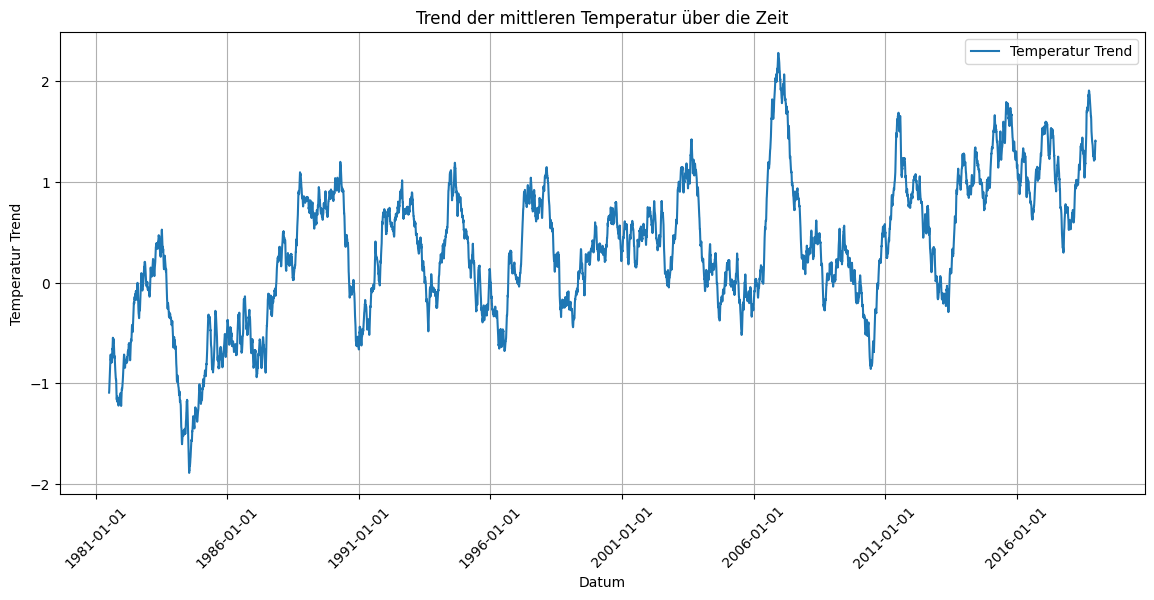

In [3]:
# Trend der Temperatur modellieren
# Anzeigen des Trends (Datum nur alle 5 Jahre)
xticks = pd.date_range(
    start=df_train.index.min().replace(month=1, day=1),
    end=df_train.index.max(),
    freq='5YS'   # 5-year start frequency
)

plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_trend'], label='Temperatur Trend')
plt.xlabel('Datum')
plt.ylabel('Temperatur Trend')
plt.title('Trend der mittleren Temperatur über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()

plt.show()

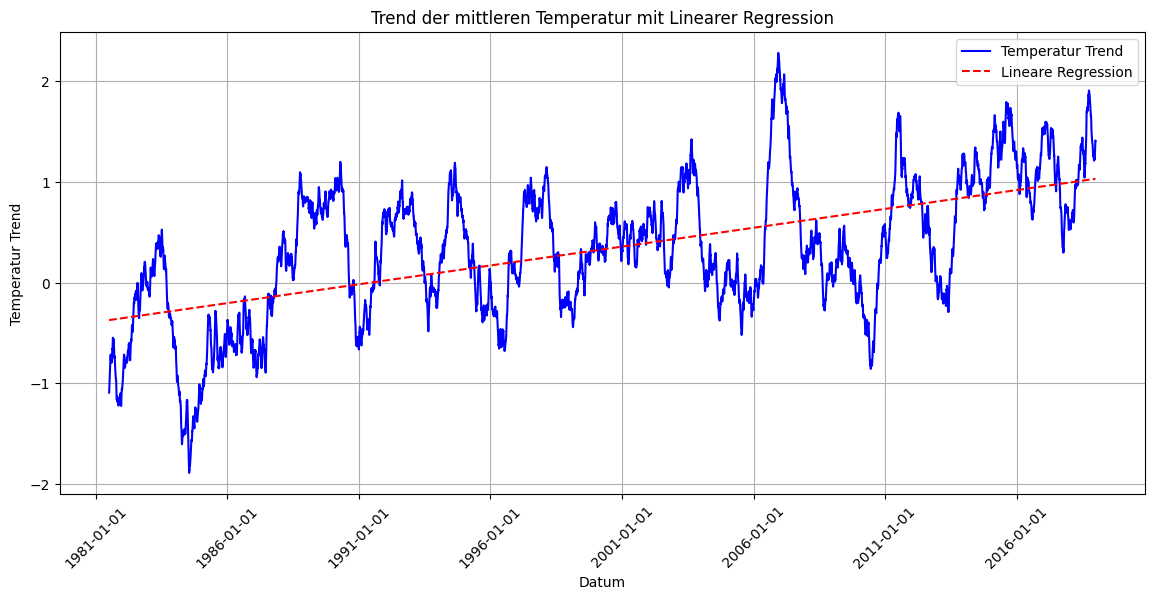

In [4]:
# Fitten einer Linearen Regression
from sklearn.linear_model import LinearRegression
# Umwandeln des Datums in eine numerische Darstellung (z.B. Tage seit Startdatum)
X = (df_train.index - df_train.index.min()).days.values.reshape(-1, 1)
y = df_train['temp_trend'].values
temp_trend_model = LinearRegression()
temp_trend_model.fit(X, y)
temp_trend_pred = temp_trend_model.predict(X)

# Plotten des Trends und der linearen Regression
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_trend'], label='Temperatur Trend', color='blue')
plt.plot(df_train.index, temp_trend_pred, label='Lineare Regression', color='red', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Temperatur Trend')
plt.title('Trend der mittleren Temperatur mit Linearer Regression')
plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()
plt.show()


#### Modellieren Saisonalität Temperatur

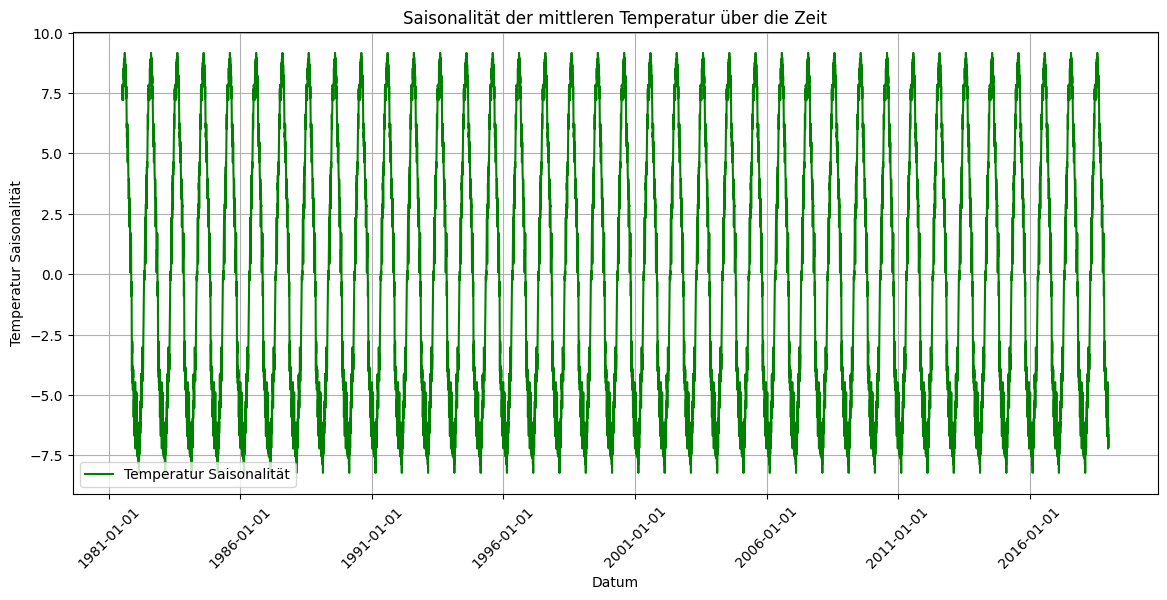

In [5]:
# Saisonalität der Tepmeratur plotten
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_season'], label='Temperatur Saisonalität', color='green')
plt.xlabel('Datum')
plt.ylabel('Temperatur Saisonalität')
plt.title('Saisonalität der mittleren Temperatur über die Zeit')
plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()
plt.show()

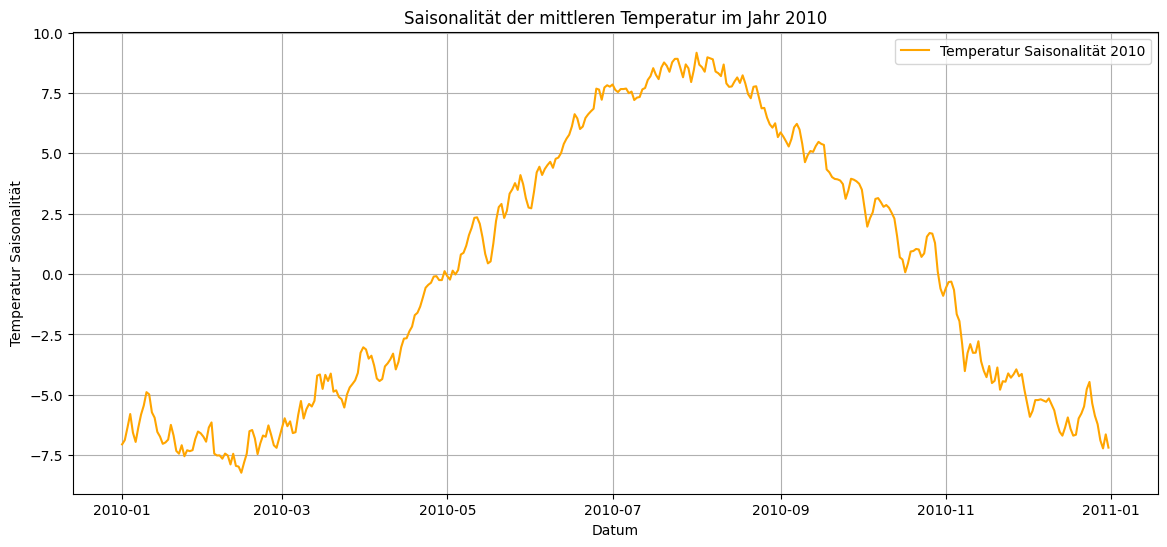

In [6]:
# Welle für ein Jahr plotten
plt.figure(figsize=(14, 6))
one_year = df_train['temp_season']['2010-01-01':'2010-12-31']
plt.plot(one_year.index, one_year.values, label='Temperatur Saisonalität 2010', color='orange')
plt.xlabel('Datum')
plt.ylabel('Temperatur Saisonalität')
plt.title('Saisonalität der mittleren Temperatur im Jahr 2010')
plt.grid(True)
plt.legend()
plt.show()


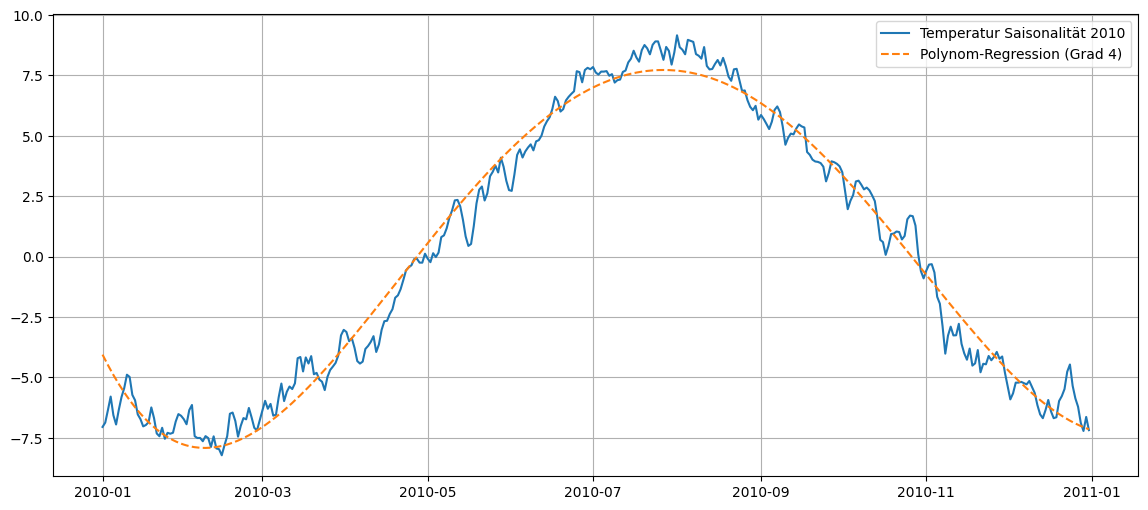

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


one_year = df_train['temp_season']['2010-01-01':'2010-12-31']

# Feature = Tag im Jahr (1–365)
day_of_year = one_year.index.dayofyear.values.reshape(-1, 1)

poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(day_of_year)

temp_season_model = LinearRegression()
temp_season_model.fit(X_poly, one_year.values)

season_pred = temp_season_model.predict(X_poly)

plt.figure(figsize=(14, 6))
plt.plot(one_year.index, one_year.values, label='Temperatur Saisonalität 2010')
plt.plot(one_year.index, season_pred, label='Polynom-Regression (Grad 4)', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()


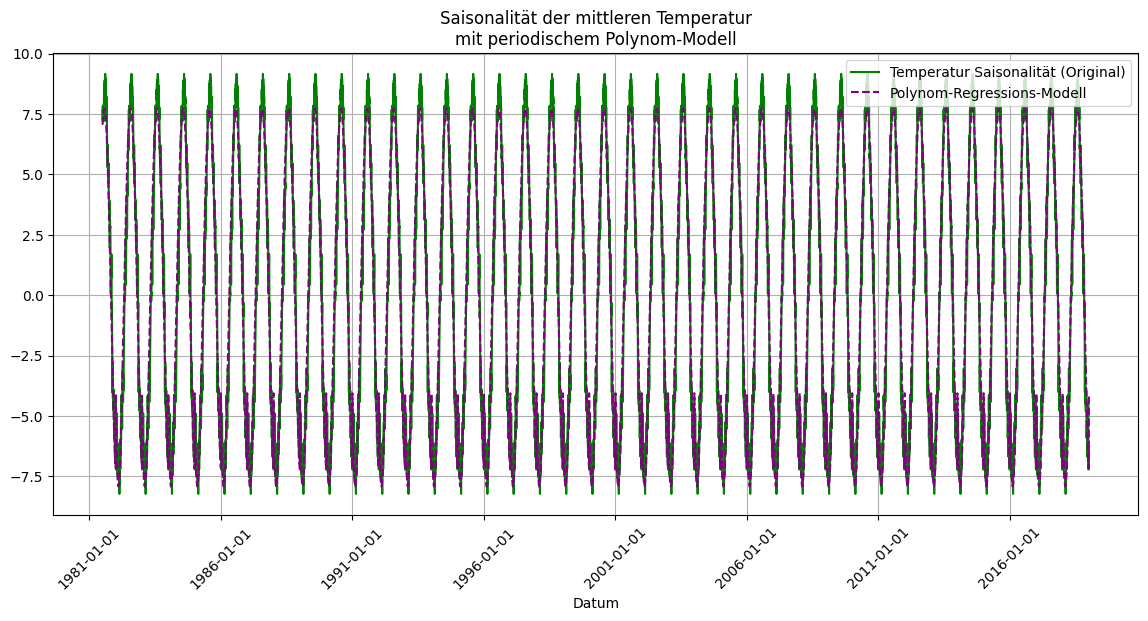

In [8]:
# Tag des Jahres für alle Daten
day_of_year_all = df_train.index.dayofyear.values.reshape(-1, 1)
X_poly_all = poly.transform(day_of_year_all)

season_pred_all = temp_season_model.predict(X_poly_all)

plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_season'], label='Temperatur Saisonalität (Original)', color='green')
plt.plot(df_train.index, season_pred_all, label='Polynom-Regressions-Modell', color='purple', linestyle='--')
plt.xlabel("Datum")
plt.xticks(xticks, rotation=45)
plt.title("Saisonalität der mittleren Temperatur\nmit periodischem Polynom-Modell")
plt.grid(True)
plt.legend()
plt.show()


#### Modellieren Residuen Temperatur
Aus der ACF und PACF der Residuen der Temperaturkomponente haben wir erkannt, dass ein AR(3)-Modell passend wäre. Daher modellieren wir die Residuen der Temperatur mit einem AR(3)-Modell.

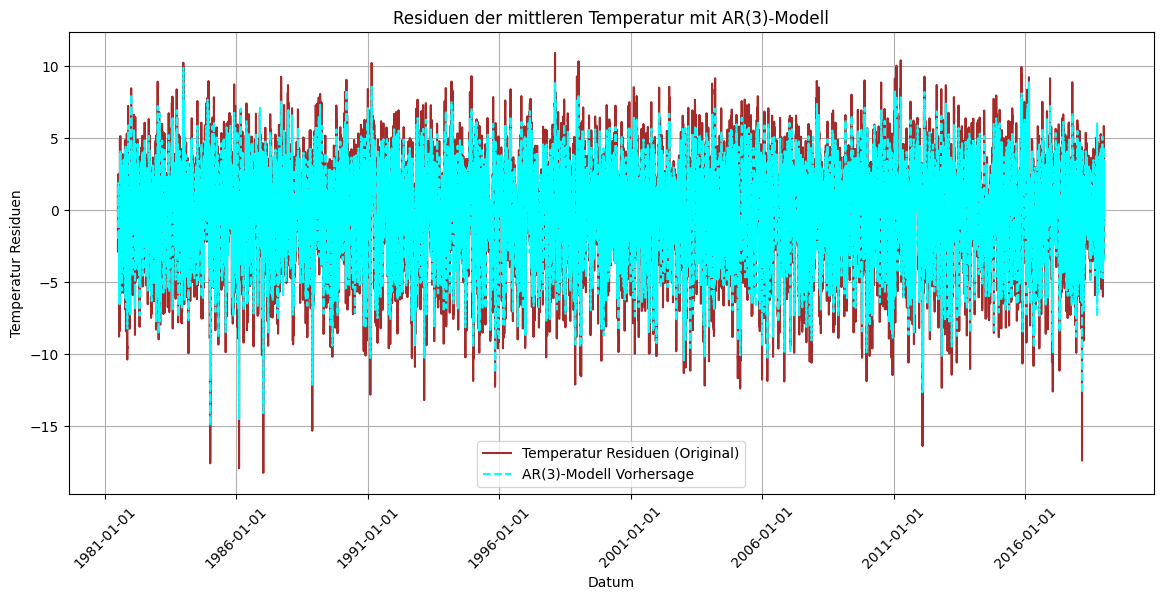

In [9]:
# Modellieren der Residuen mit einem AR(3)-Modell
from statsmodels.tsa.ar_model import AutoReg
temp_resid_model = AutoReg(df_train['temp_resid'], lags=3).fit()
resid_pred = temp_resid_model.predict(start=0, end=len(df_train)-1)
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['temp_resid'], label='Temperatur Residuen (Original)', color='brown')
plt.plot(df_train.index, resid_pred, label='AR(3)-Modell Vorhersage', color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Temperatur Residuen')
plt.title('Residuen der mittleren Temperatur mit AR(3)-Modell')
plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()
plt.show()

#### Zusammensetzung der Temperaturkomponenten
Nun müssen die einzelnen modellierten Komponenten der Temperatur wieder zusammengesetzt werden, um die gesamte Temperatur zu erhalten. Dies geschieht durch Addition der modellierten Trend-, Saisonalitäts- und Residuenkomponenten. Die Werte sollen anschliessend auch dafür benutzt werden, um zukünftige Temperaturen vorherzusagen.

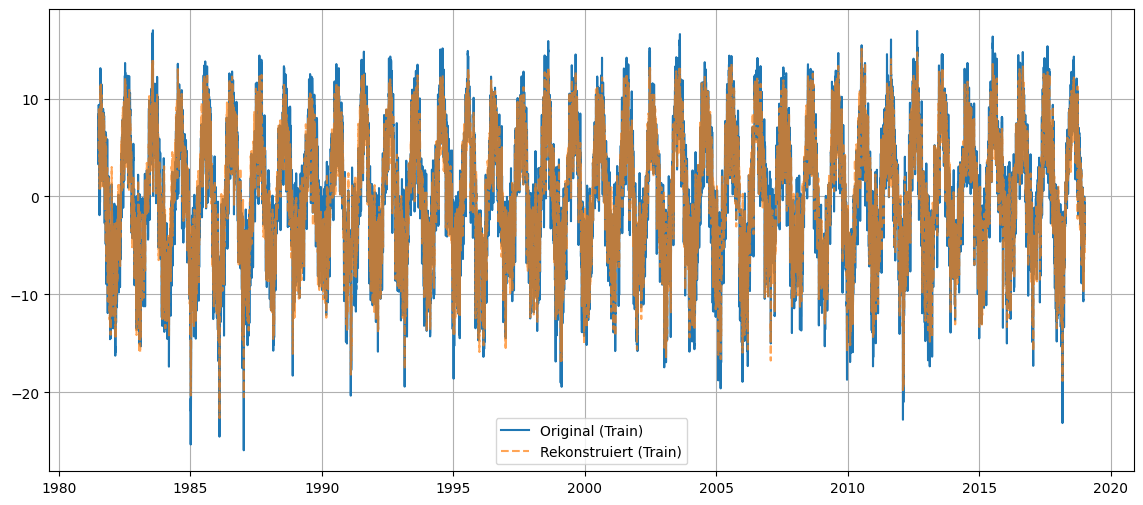

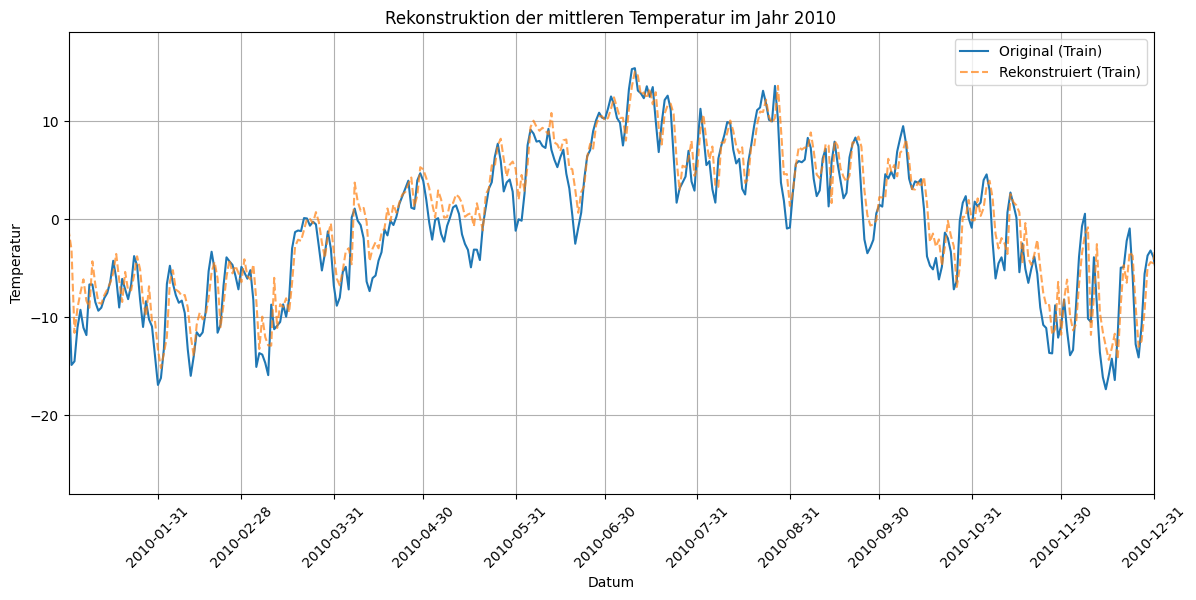

In [10]:
# Trend vorhersagen
X_train_days = (df_train.index - df_train.index.min()).days.values.reshape(-1, 1)
temp_trend_train_pred = temp_trend_model.predict(X_train_days)

# Saisonalität vorhersagen
day_of_year_train = df_train.index.dayofyear.values.reshape(-1, 1)
temp_season_train_pred = poly.transform(day_of_year_train)
temp_season_train_pred = temp_season_model.predict(temp_season_train_pred)

# Residuen vorhersagen
temp_resid_train_pred = temp_resid_model.predict(start=df_train.index[0], end=df_train.index[-1])
# Gesamte Temperatur rekonstruieren
temp_train_reconstructed = temp_trend_train_pred + temp_season_train_pred + temp_resid_train_pred.values

# Plotten der rekonstruierten Temperatur gegen die Originalwerte
plt.figure(figsize=(14,6))
plt.plot(df_train.index, df_train['temp_trend'] + df_train['temp_season'] + df_train['temp_resid'], 
         label='Original (Train)', alpha=1)
plt.plot(df_train.index, temp_train_reconstructed, 
         label='Rekonstruiert (Train)', linestyle='--', alpha=0.7)
plt.legend()
plt.grid(True)
plt.show()

# Zoom auf ein Jahr
zoom_xticks = pd.date_range(start='2010-01-01', end='2010-12-31', freq='ME')
plt.figure(figsize=(14,6))
plt.plot(df_train.index, df_train['temp_trend'] + df_train['temp_season'] + df_train['temp_resid'], 
         label='Original (Train)', alpha=1)
plt.plot(df_train.index, temp_train_reconstructed, 
         label='Rekonstruiert (Train)', linestyle='--', alpha=0.7)
plt.xlim(pd.Timestamp('2010-01-01'), pd.Timestamp('2010-12-31'))
plt.xticks(zoom_xticks, rotation=45)
plt.xlabel("Datum")
plt.ylabel("Temperatur")
plt.title("Rekonstruktion der mittleren Temperatur im Jahr 2010")
plt.legend()
plt.grid(True)
plt.show()


In der Rekonstruktion sieht man, dass einige Informationen verloren gehen, aber die Daten grundsätzlich gut rekonstruiert werden können. Nun noch die Vorhersagen in die Zukunft auf dem Testset anwenden.

C:\Users\Sandra\AppData\Local\Temp\ipykernel_18336\3511325251.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = temp_resid_model.params[0]  # Konstante
C:\Users\Sandra\AppData\Local\Temp\ipykernel_18336\3511325251.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred += temp_resid_model.params[j+1] * lags[-(j+1)]


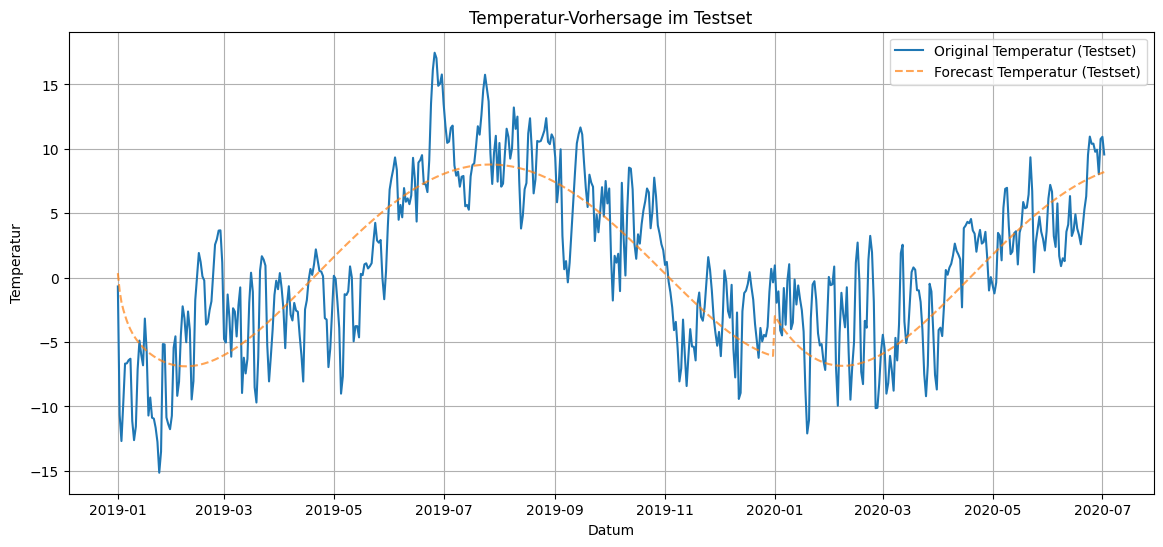

MAE: 3.0683739524910685
RMSE: 3.783220623982811


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Trend für das Testset vorhersagen
X_test_days = (df_test.index - df_train.index.min()).days.values.reshape(-1, 1)
temp_trend_test_pred = temp_trend_model.predict(X_test_days)


# Saisonalität für das Testset vorhersagen
day_of_year_test = df_test.index.dayofyear.values.reshape(-1, 1)
X_poly_test = poly.transform(day_of_year_test)
temp_season_test_pred = temp_season_model.predict(X_poly_test)

# Residuen für das Testset vorhersagen
# Letzte 3 Residuen aus dem Trainingsset holen
temp_last_resid_lags = df_train['temp_resid'].iloc[-3:].values

# Leere Serie für Test Vorhersagen
temp_resid_test_pred = []

# Manuelle rolling prediction
for i in range(len(df_test)):
    if i < 3:
        # Für die ersten 3 Vorhersagen: Verwende tatsächliche Trainingswerte
        lags = temp_last_resid_lags[-(3-i):].tolist() + temp_resid_test_pred[:i]
    else:
        # Danach: Verwende die letzten 3 Vorhersagen
        lags = temp_resid_test_pred[-3:]
    
    # Vorhersage basierend auf den Lags
    pred = temp_resid_model.params[0]  # Konstante
    for j in range(min(3, len(lags))):
        pred += temp_resid_model.params[j+1] * lags[-(j+1)]
    
    temp_resid_test_pred.append(pred)

temp_resid_test_pred = np.array(temp_resid_test_pred)

# Gesamte Temperatur rekonstruieren
temp_test_forecast = temp_trend_test_pred + temp_season_test_pred + temp_resid_test_pred

# Visualisierung: Original vs. Forecast
plt.figure(figsize=(14,6))
plt.plot(df_test.index,
         df_test['temp_trend'] + df_test['temp_season'] + df_test['temp_resid'],
         label='Original Temperatur (Testset)', alpha=1)
plt.plot(df_test.index,
         temp_test_forecast,
         label='Forecast Temperatur (Testset)', linestyle='--', alpha=0.7)
plt.xlabel("Datum")
plt.ylabel("Temperatur")
plt.title("Temperatur-Vorhersage im Testset")
plt.legend()
plt.grid(True)
plt.show()

# Fehlerkennzahlen

y_true = df_test['temp_trend'] + df_test['temp_season'] + df_test['temp_resid']
y_pred = temp_test_forecast

print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

Die Rekonstruktion der gesamten Temperatur auf dem Testset erfolgt durch Addition der vorhergesagten Trend-, Saisonalitäts- und Residuenkomponenten. Sie sieht in ordnung aus. Jedoch wird klar, dass ein grosser Teil der Rekonstruktion durch die Saisonalität kommt. Das liegt aber daranm, dass die Saisonalität den grössten Anteil an der Varianz der Temperatur hat und das AR(3)-Modell nur zu beginn der Testperiode gut vorhersagen kann. Der Trend hat insgesammt nur einen sehr kleinen Einfluss auf die Temperatur. Es ist deshalb wichtig zu wissen, dass man für genauere Vorhersagen jeweils nur gerade die nächsten Tage vorhersagen kann, da das AR-Modell nur auf den letzten Werten basiert.

### Modellieren des Niederschlags
Aufgrund der schlechten Daten und der kleinen Korrelation zum Wasserstand haben wir uns entschieden, den Niederschlag vorerst nicht zu modellieren und für die Vorhersage zu benutzen.

### Modellierung des Abflussvolumens
#### Modellieren Trend Abflussvolumen

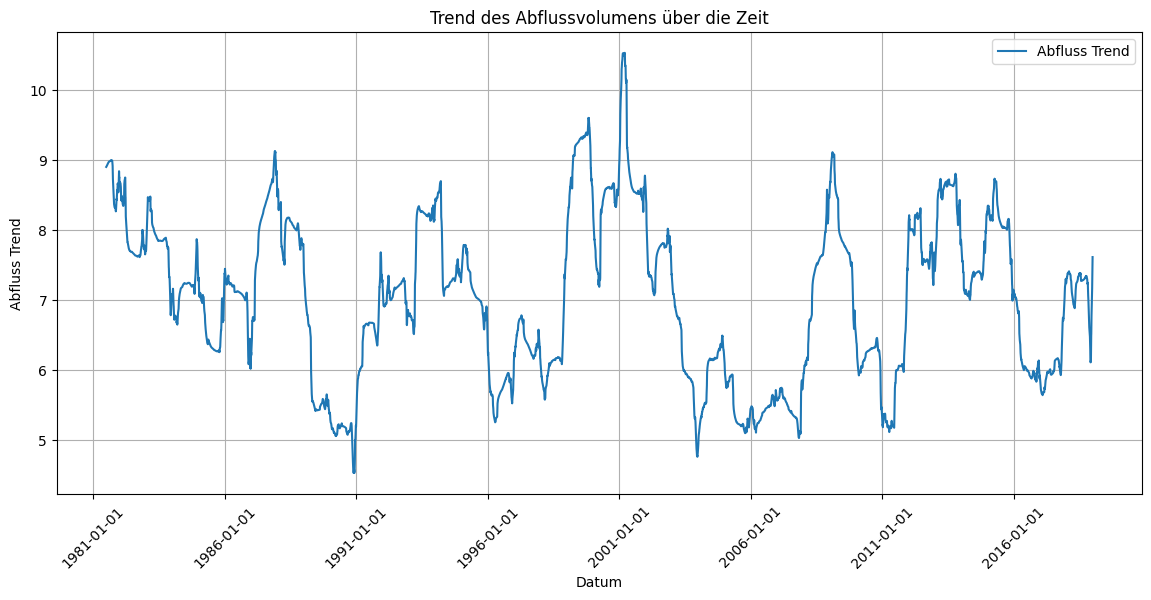

In [12]:
# Trend des Abfluss modellieren
# Anzeigen des Trends (Datum nur alle 5 Jahre)
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['discharge_trend'], label='Abfluss Trend')
plt.xlabel('Datum')
plt.ylabel('Abfluss Trend')
plt.title('Trend des Abflussvolumens über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()

plt.show()

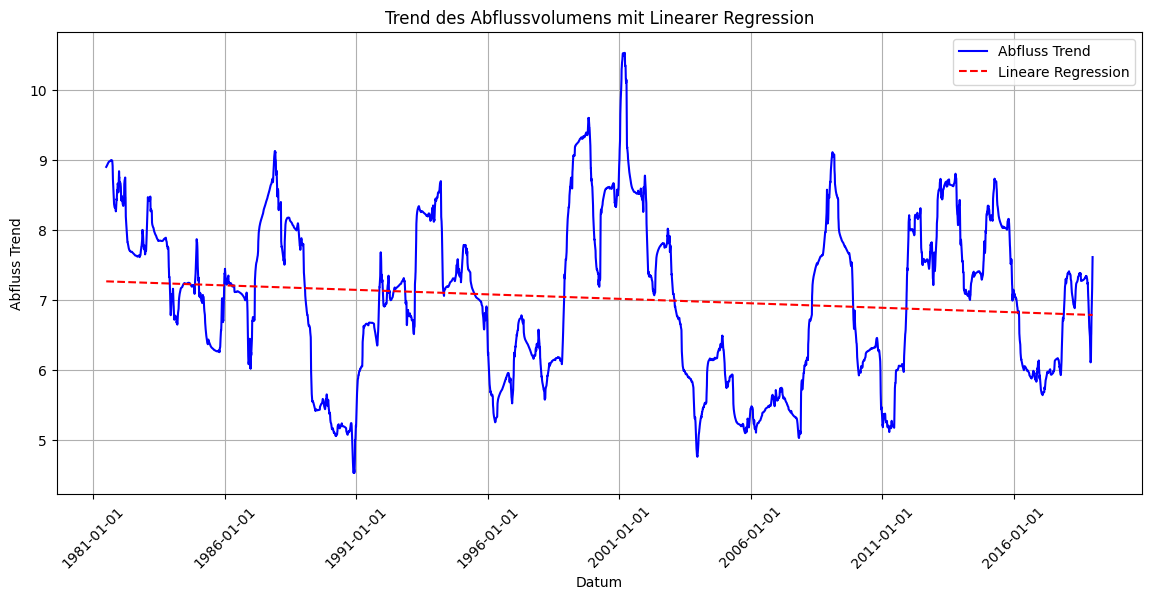

In [13]:
# Feature: Tage seit Startdatum
X = (df_train.index - df_train.index.min()).days.values.reshape(-1, 1)
y = df_train['discharge_trend'].values

# Lineare Regression auf polynomiale Features
discharge_trend_model = LinearRegression()
discharge_trend_model.fit(X, y)

# Vorhersage
discharge_trend_pred = discharge_trend_model.predict(X)

# Plotten
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['discharge_trend'], label='Abfluss Trend', color='blue')
plt.plot(df_train.index, discharge_trend_pred, label='Lineare Regression', color='red', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Abfluss Trend')
plt.title('Trend des Abflussvolumens mit Linearer Regression')
plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.legend()
plt.show()


Die Daten sind nicht sonderlich gut zu reproduzieren mit einfachen linearen Modellen. Jedoch verzichten wir hier fürs erste auf weitere Trendanalysen.

#### Modellieren Saisonalität Abflussvolumen

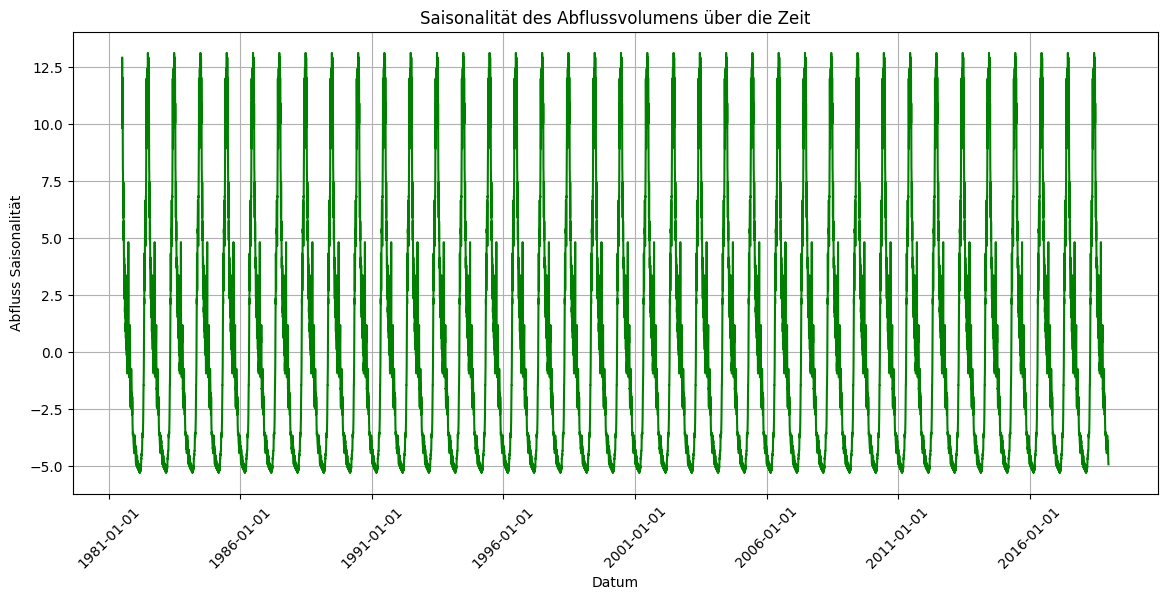

In [14]:
# Plotten der Saisonalität des Abflussvolumens
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['discharge_season'], label='Abfluss Saisonalität', color='green')
plt.xlabel('Datum')
plt.ylabel('Abfluss Saisonalität')
plt.title('Saisonalität des Abflussvolumens über die Zeit')
plt.xticks(xticks, rotation=45)
plt.grid(True)
plt.show()

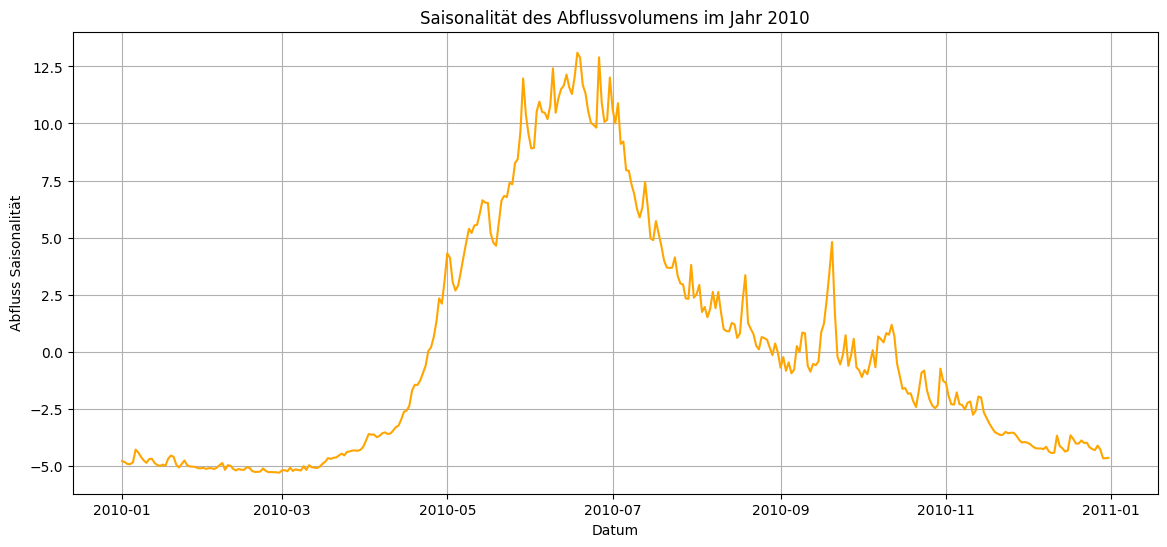

In [15]:
# Welle für ein Jahr plotten
plt.figure(figsize=(14, 6))
one_year = df_train['discharge_season']['2010-01-01':'2010-12-31']
plt.plot(one_year.index, one_year.values, label='Abfluss Saisonalität 2010', color='orange')
plt.xlabel('Datum')
plt.ylabel('Abfluss Saisonalität')
plt.title('Saisonalität des Abflussvolumens im Jahr 2010')
plt.grid(True)
plt.show()

In [16]:
df['dayofyear'] = df.index.dayofyear

# Durchschnittliche Saisonalität pro Tag des Jahres
discharche_seasonal_lookup = df.groupby('dayofyear')['discharge_season'].mean()

Hier haben wir uns dazu entschieden, die Saisonalität des Abflussvolumens durch den Durchschnittswert pro Tag des Jahres zu modellieren. In der Prognose wird dann jeweils der entsprechende Tageswert benutzt.

#### Modellieren Residuen Abflussvolumen
Die ACF und PACF der Residuen des Abflussvolumens deuten darauf hin, dass ein AR(5)-Modell oder vielleicht sogar ein AR(12)-Modell passend wäre. Zuerst erstellen wir ein AR(5)-Modell und danach noch ein AR(12)-Modell, um die Residuen des Abflussvolumens zu modellieren. Bei der betrachtung der beiden Modelle sehen wir keinen grossen Unterschied in der Vorhersagequalität. Deshalb entscheiden wir uns fürs erste für das AR(5)-Modell, da es weniger komplex ist.

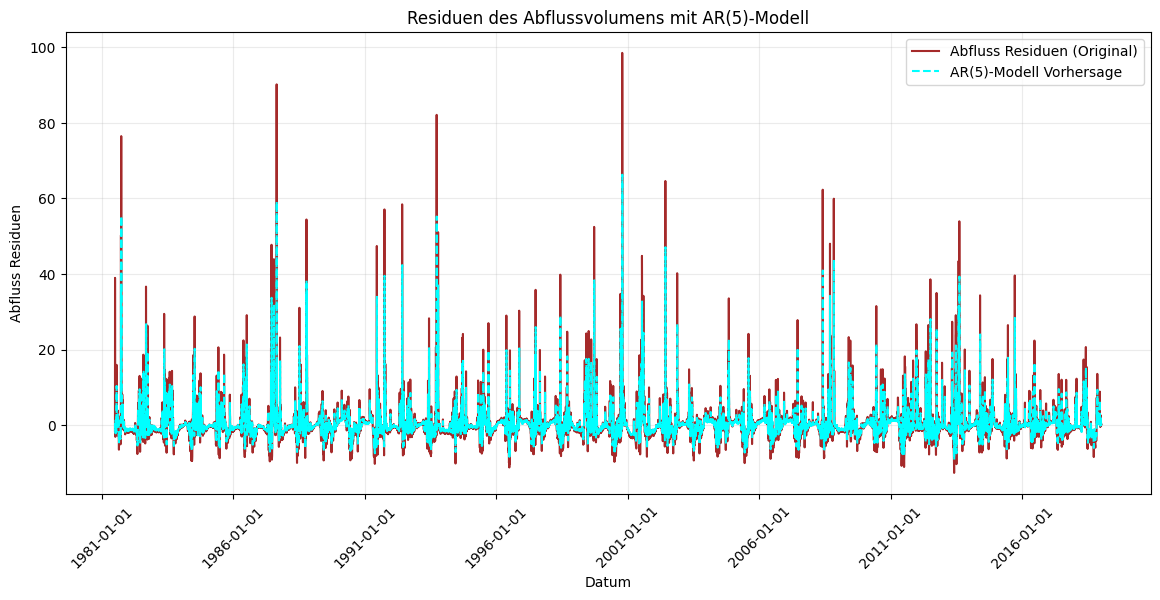

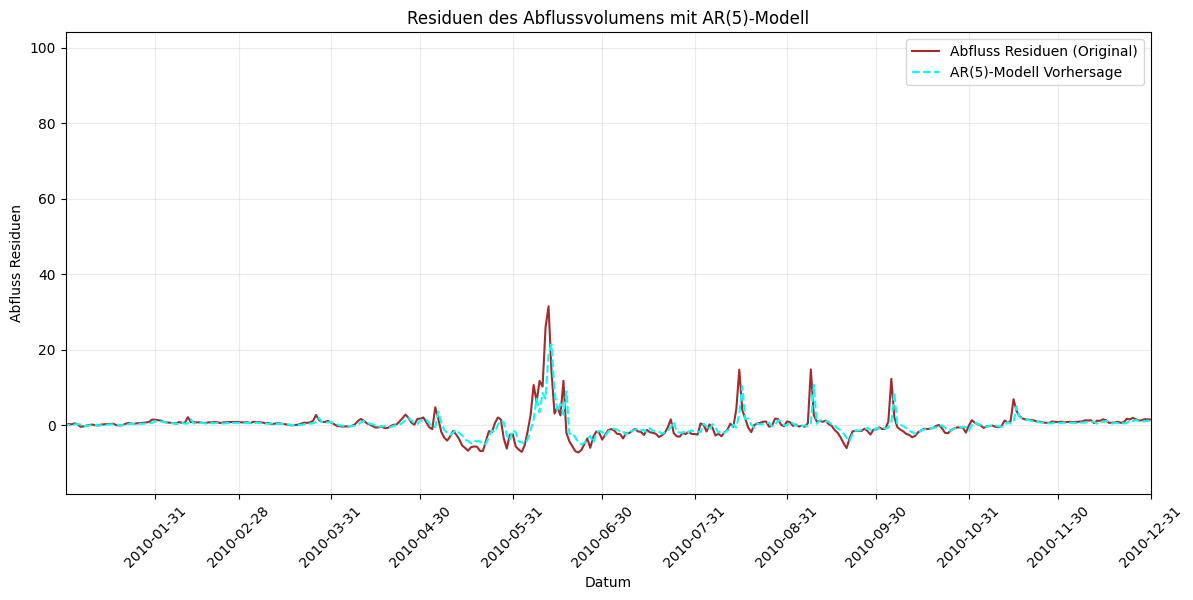

In [17]:
dicharge_resid_model_5 = AutoReg(df_train['discharge_resid'], lags=5).fit()
resid_pred_5 = dicharge_resid_model_5.predict(start=0, end=len(df_train)-1)
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['discharge_resid'], label='Abfluss Residuen (Original)', color='brown')
plt.plot(df_train.index, resid_pred_5, label='AR(5)-Modell Vorhersage', color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Abfluss Residuen')
plt.title('Residuen des Abflussvolumens mit AR(5)-Modell')
plt.xticks(xticks, rotation=45)
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

# Plotten nur eines Jahres der Residuen mit AR(5)-Modell
zoom_xticks = pd.date_range("2010-01-01", "2011-01-01", freq="ME")
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['discharge_resid'], label='Abfluss Residuen (Original)', color='brown')
plt.plot(df_train.index, resid_pred_5, label='AR(5)-Modell Vorhersage', color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.xlim(pd.Timestamp("2010-01-01"), pd.Timestamp("2010-12-31"))
plt.ylabel('Abfluss Residuen')
plt.title('Residuen des Abflussvolumens mit AR(5)-Modell')
plt.xticks(zoom_xticks, rotation=45)
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

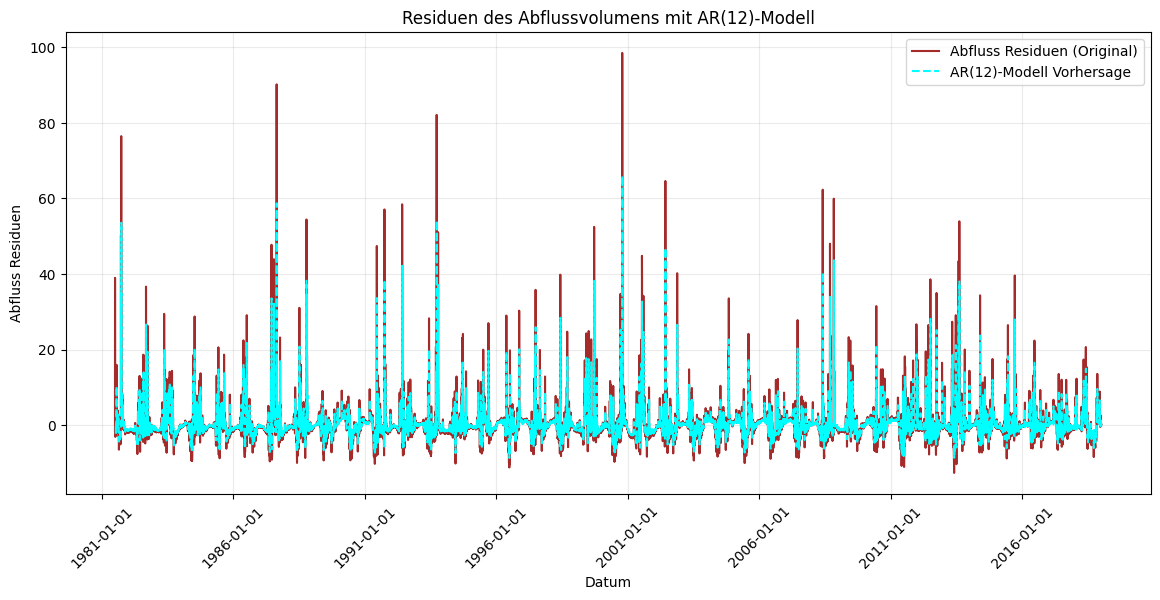

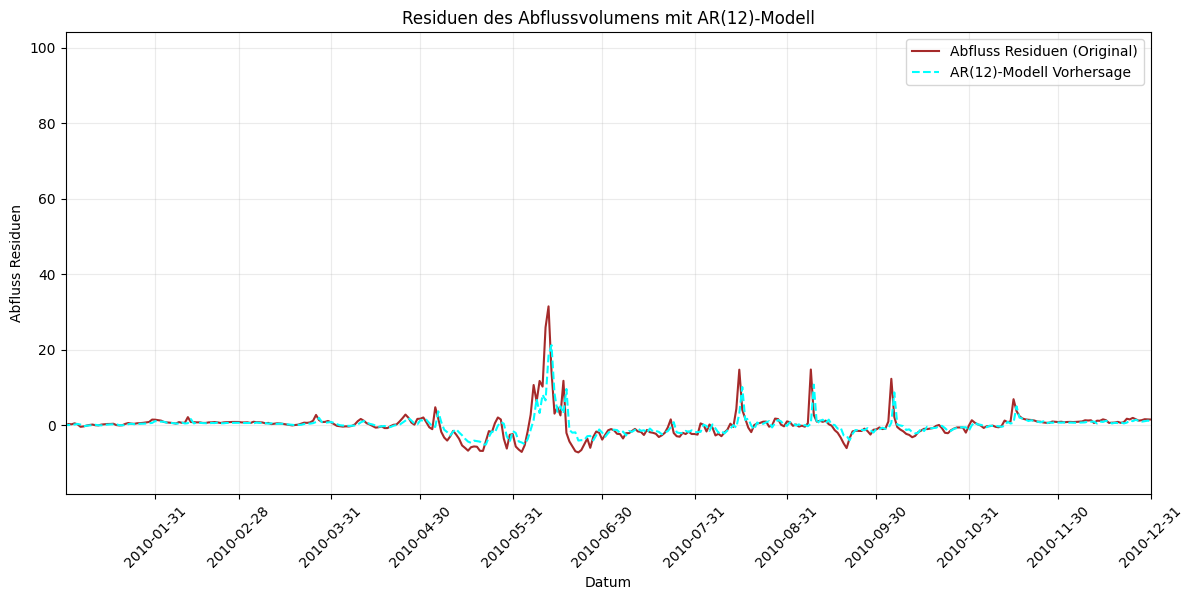

In [18]:
dicharge_resid_model_12 = AutoReg(df_train['discharge_resid'], lags=12).fit()
resid_pred_12 = dicharge_resid_model_12.predict(start=0, end=len(df_train)-1)
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['discharge_resid'], label='Abfluss Residuen (Original)', color='brown')
plt.plot(df_train.index, resid_pred_12, label='AR(12)-Modell Vorhersage', color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Abfluss Residuen')
plt.title('Residuen des Abflussvolumens mit AR(12)-Modell')
plt.xticks(xticks, rotation=45)
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

# Plotten nur eines Jahres der Residuen mit AR(12)-Modell
zoom_xticks = pd.date_range("2010-01-01", "2011-01-01", freq="ME")
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['discharge_resid'], label='Abfluss Residuen (Original)', color='brown')
plt.plot(df_train.index, resid_pred_12, label='AR(12)-Modell Vorhersage', color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.xlim(pd.Timestamp("2010-01-01"), pd.Timestamp("2010-12-31"))
plt.ylabel('Abfluss Residuen')
plt.title('Residuen des Abflussvolumens mit AR(12)-Modell')
plt.xticks(zoom_xticks, rotation=45)
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

#### Zusammensetzung des Abflussvolumens

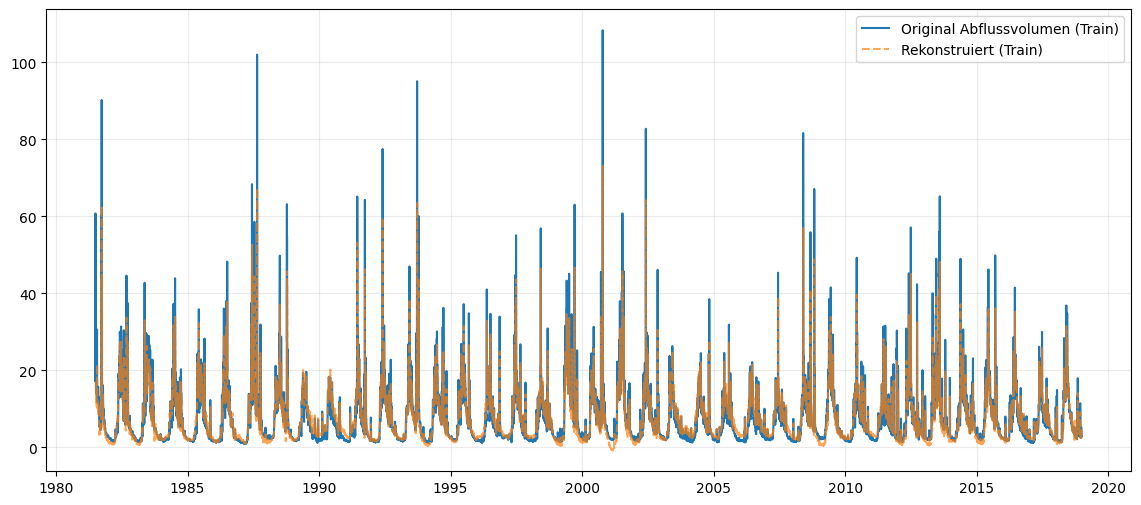

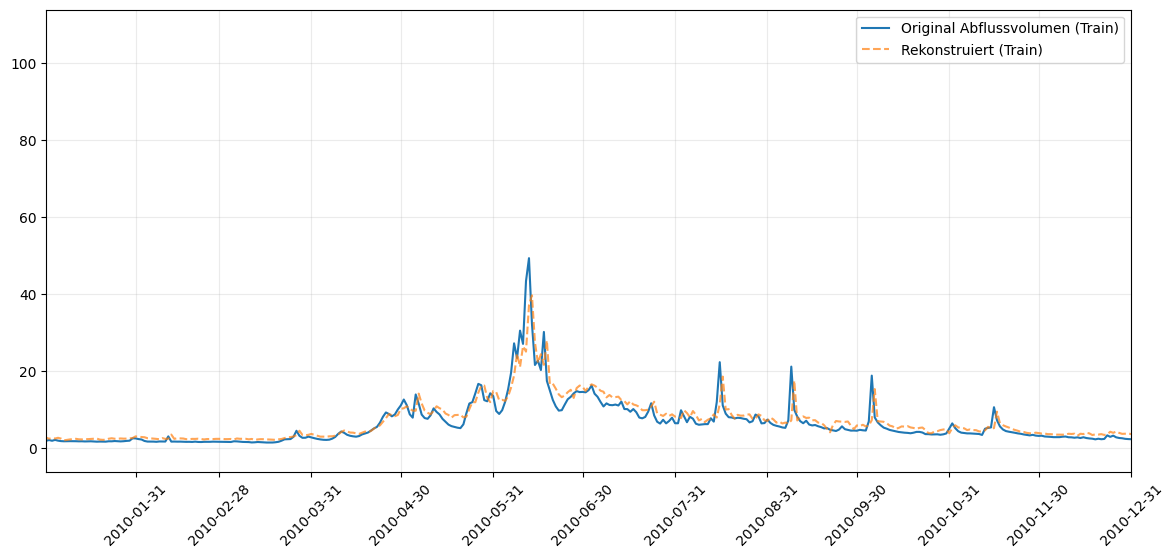

In [19]:
# Vorhersagen des Abflussvolumens auf dem Trainingsset
# Trend vorhersagen
X_train_days = (df_train.index - df_train.index.min()).days.values.reshape(-1, 1)
discharge_trend_train_pred = discharge_trend_model.predict(X_train_days)

# Saisonalität vorhersagen
day_of_year_train = df_train.index.dayofyear.values.reshape(-1, 1)
discharge_season_train_pred = discharche_seasonal_lookup.loc[day_of_year_train.flatten()].values

# Residuen vorhersagen
discharge_resid_train_pred = dicharge_resid_model_5.predict(start=df_train.index[0], end=df_train.index[-1])

# Gesamtes Abflussvolumen rekonstruieren
discharge_train_reconstructed = (discharge_trend_train_pred + 
                                  discharge_season_train_pred + 
                                  discharge_resid_train_pred.values)

# Plotten der rekonstruierten Abflussvolumen gegen die Originalwerte
plt.figure(figsize=(14,6))
plt.plot(df_train.index, df_train['discharge_trend'] + df_train['discharge_season'] + df_train['discharge_resid'], label='Original Abflussvolumen (Train)', alpha=1)
plt.plot(df_train.index, discharge_train_reconstructed, label='Rekonstruiert (Train)', linestyle='--', alpha=0.7)
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

# Zoom auf ein Jahr
zoom_xticks = pd.date_range("2010-01-01", "2010-12-31", freq="ME")
plt.figure(figsize=(14,6))
plt.plot(df_train.index, df_train['discharge_trend'] + df_train['discharge_season'] + df_train['discharge_resid'], label='Original Abflussvolumen (Train)', alpha=1)
plt.plot(df_train.index, discharge_train_reconstructed, label='Rekonstruiert (Train)', linestyle='--', alpha=0.7)
plt.xlim(pd.Timestamp("2010-01-01"), pd.Timestamp("2010-12-31"))
plt.xticks(zoom_xticks, rotation=45)
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

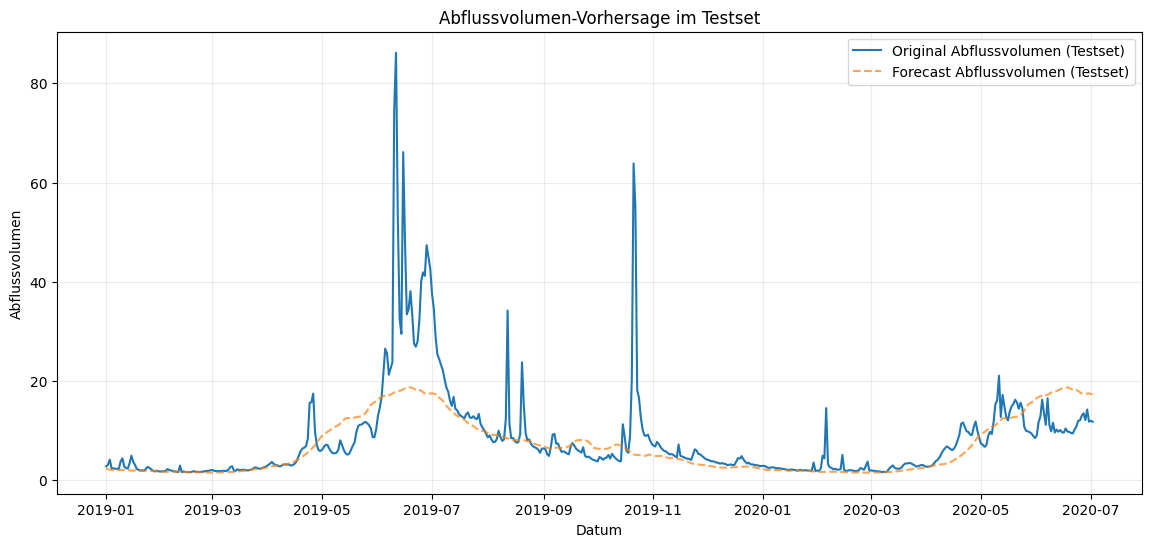

MAE: 3.206947607037313
RMSE: 7.505324213974347


In [20]:
# Vorhersage des Abflussvolumens im Testset
# Trend für das Testset vorhersagen
X_test_days = (df_test.index - df_train.index.min()).days.values.reshape(-1, 1)
discharge_trend_test_pred = discharge_trend_model.predict(X_test_days)

# Saisonalität für das Testset vorhersagen
day_of_year_test = df_test.index.dayofyear.values.reshape(-1, 1)
discharge_season_test_pred = discharche_seasonal_lookup.loc[day_of_year_test.flatten()].values

# Residuen für das Testset vorhersagen (AR(5))
# Die letzten 5 Werte aus dem Training als Startwerte verwenden
discharge_last_resid_lags = df_train['discharge_resid'].iloc[-5:].values

# Eine leere Liste für die Testvorhersagen erstellen
discharge_resid_test_pred = []

# Manuelle rolling prediction
for i in range(len(df_test)):
    if i < 5:
        # Für die ersten 5 Vorhersagen: Verwende tatsächliche Trainingswerte
        lags = discharge_last_resid_lags[-(5-i):].tolist() + discharge_resid_test_pred[:i]
    else:
        # Danach: Verwende die letzten 5 Vorhersagen
        lags = discharge_resid_test_pred[-5:]
    
    # Vorhersage basierend auf den Lags
    pred = dicharge_resid_model_5.params.iloc[0]  # Konstante
    for j in range(min(5, len(lags))):
        pred += dicharge_resid_model_5.params.iloc[j+1] * lags[-(j+1)]
    
    discharge_resid_test_pred.append(pred)

discharge_resid_test_pred = np.array(discharge_resid_test_pred)

# Gesamtes Abflussvolumen rekonstruieren
discharge_test_forecast = (discharge_trend_test_pred + 
                           discharge_season_test_pred + 
                           discharge_resid_test_pred)

# Visualisierung: Original vs. Forecast
plt.figure(figsize=(14,6))
plt.plot(df_test.index,
         df_test['discharge_trend'] + df_test['discharge_season'] + df_test['discharge_resid'],
         label='Original Abflussvolumen (Testset)', alpha=1)

plt.plot(df_test.index, 
         discharge_test_forecast,
         label='Forecast Abflussvolumen (Testset)', linestyle='--', alpha=0.7)
plt.xlabel("Datum")
plt.ylabel("Abflussvolumen")
plt.title("Abflussvolumen-Vorhersage im Testset")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

# Fehlerkennzahlen
y_true = df_test['discharge_trend'] + df_test['discharge_season'] + df_test['discharge_resid']
y_pred = discharge_test_forecast
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

Ähnlich wie bei den Temperaturen sehen wir auch hier, dass die Rekonstruktion des Abflussvolumens durch die Saisonalität dominiert wird. Das AR-Modell kann nur kurzfristig gute Vorhersagen machen. Gerade die Extremeren Werte werden vor allem durch die Residuen modelliert, Deshalb sieht der Grosse Peak im Abflussvolumen im Testsatz enorm abgefalcht aus.

### Modellieren des Wasserstands durch die obgien Variablen
Ziel ist es nun den Wasserstand durch die anderen Variablen zu modellieren. Dazu soll zuerst der Wasserstand durch die beiden anderen "echten" Variablen (`Temperatur` und `Abflussvolumen`) modelliert werden. Daurch sollen die benötigten Feature Importances für die beiden Variablen erhalten werden. Anschliessend soll der Wasserstand durch die modellierten Variablen (Trend, Saisonalität, Residuen) der Temperatur und des Abflussvolumens modelliert werden. So wäre am Ende das Ziel, mit den einzelnen kleinen Modellen die wir als Vorhersage zur Temperatur und dem Abflussvolumen erstellt haben, zusammengesetzt den Wasserstand vorherzusagen.

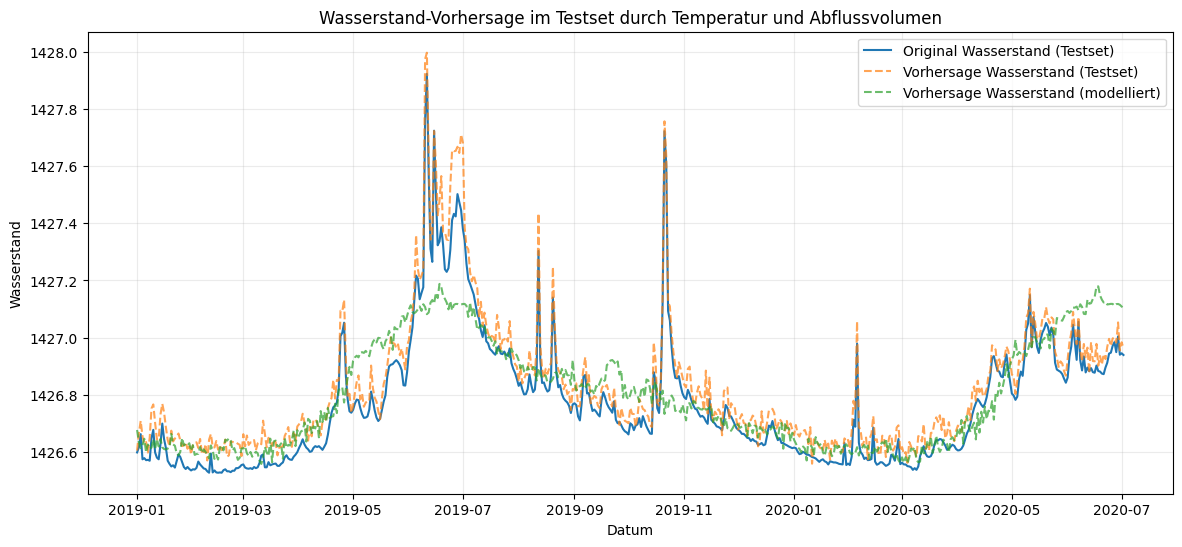

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Vorhersagen des Wasserstands durch Temperatur und Abflussvolumen
wasserstand_y = (df_train['wl_trend'] + df_train['wl_season'] + df_train['wl_resid'])
abfluss_x = (df_train['discharge_trend'] + df_train['discharge_season'] + df_train['discharge_resid'])
temperatur_x = (df_train['temp_trend'] + df_train['temp_season'] + df_train['temp_resid'])

# Model erstellen
X_train = pd.DataFrame({
    'abfluss': abfluss_x,
    'temperatur': temperatur_x
})

wasserstand_model = RandomForestRegressor(n_estimators=100, random_state=42)
wasserstand_model.fit(X_train, wasserstand_y)

# Vorhersage im Testset
abfluss_x_test = (df_test['discharge_trend'] + df_test['discharge_season'] + df_test['discharge_resid'])
temperatur_x_test = (df_test['temp_trend'] + df_test['temp_season'] + df_test['temp_resid'])
X_test = pd.DataFrame({
    'abfluss': abfluss_x_test,
    'temperatur': temperatur_x_test
})
wasserstand_test_pred = wasserstand_model.predict(X_test)

# Vorhersage mit den Vorhergesagten Modellen
abfluss_x_test_modelliert = discharge_test_forecast
temperatur_x_test_modelliert = temp_test_forecast
X_test_modelliert = pd.DataFrame({
    'abfluss': abfluss_x_test_modelliert,
    'temperatur': temperatur_x_test_modelliert
})

wasserstand_test_pred_modelliert = wasserstand_model.predict(X_test_modelliert)


# Visualisierung: Original vs. Vorhersage
plt.figure(figsize=(14,6))
plt.plot(df_test.index,
         df_test['wl_trend'] + df_test['wl_season'] + df_test['wl_resid'],
         label='Original Wasserstand (Testset)', alpha=1)
plt.plot(df_test.index,
         wasserstand_test_pred,
         label='Vorhersage Wasserstand (Testset)', linestyle='--', alpha=0.7)
plt.plot(df_test.index,
         wasserstand_test_pred_modelliert,
         label='Vorhersage Wasserstand (modelliert)', linestyle='--', alpha=0.7)
plt.xlabel("Datum")
plt.ylabel("Wasserstand")
plt.title("Wasserstand-Vorhersage im Testset durch Temperatur und Abflussvolumen")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


In [22]:
# Berechnen der Fehlerkennzahlen
y_true = df_test['wl_trend'] + df_test['wl_season'] + df_test['wl_resid']
y_pred = wasserstand_test_pred
y_pred_modelliert = wasserstand_test_pred_modelliert

print("="*60)
print("Fehlerkennzahlen für Wasserstand Vorhersage:")
print("MAE (direkt):", mean_absolute_error(y_true, y_pred))
print("RMSE (direkt):", np.sqrt(mean_squared_error(y_true, y_pred)))
print("MAE (modelliert):", mean_absolute_error(y_true, y_pred_modelliert))
print("RMSE (modelliert):", np.sqrt(mean_squared_error(y_true, y_pred_modelliert)))
print("="*60)

# Anzeigen der Feature Importances
importances = wasserstand_model.feature_importances_
feature_names = X_train.columns
print("\n" + "="*60)
print("Feature Importances für Wasserstand Modell:")
for name, importance in zip(feature_names, importances):
    print(f"Feature: {name}, Importance: {importance:.4f}")
print("="*60)


Fehlerkennzahlen für Wasserstand Vorhersage:
MAE (direkt): 0.059696652398341654
RMSE (direkt): 0.06936159622146182
MAE (modelliert): 0.09118561020029048
RMSE (modelliert): 0.13702048867304129

Feature Importances für Wasserstand Modell:
Feature: abfluss, Importance: 0.9666
Feature: temperatur, Importance: 0.0334


Das Modell funktioniert relativ gut. Mit den echten Werten ist es auf dem Testset sehr exakt. Auf den modellierten Werten macht es den gleichen Fehler wie bei der Vorhersage des Abflusses und hat mühe mit der Darstellung der Extremen Werte. Was sich jedoch auch zeigt ist, dass der Wasserstand viel stärker durch den Abfluss beeinflusst wird als durch die Temperatur. Aus interesse haben wir auch noch ein Modell nur mit der Temperatur erstellt. Dort wird klar, dass die Vorhersagequalität deutlich schlechter ist als mit beiden Variablen.

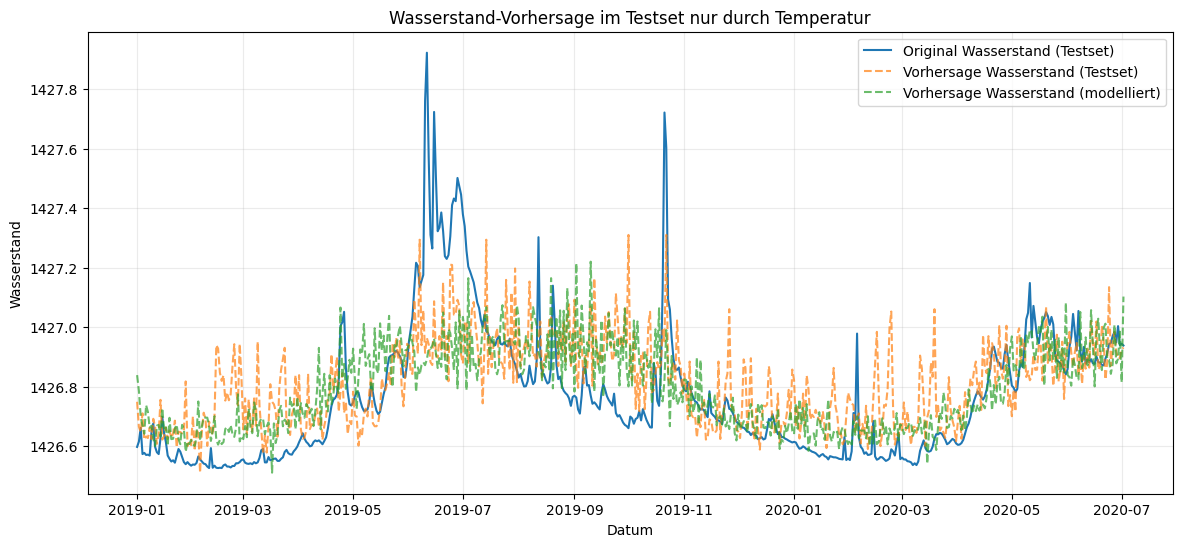

R2 (Testset): 0.3234
R2 (modelliert): 0.3828


In [23]:
from sklearn.ensemble import RandomForestRegressor

# Vorhersagen des Wasserstands durch Temperatur und Abflussvolumen
wasserstand_y = (df_train['wl_trend'] + df_train['wl_season'] + df_train['wl_resid'])
temperatur_x = (df_train['temp_trend'] + df_train['temp_season'] + df_train['temp_resid'])

# Model erstellen
X_train = pd.DataFrame({
    'temperatur': temperatur_x
})

wasserstand_model = RandomForestRegressor(n_estimators=100, random_state=42)
wasserstand_model.fit(X_train, wasserstand_y)

# Vorhersage im Testset
temperatur_x_test = (df_test['temp_trend'] + df_test['temp_season'] + df_test['temp_resid'])
X_test = pd.DataFrame({
    'temperatur': temperatur_x_test
})
wasserstand_test_pred = wasserstand_model.predict(X_test)

# Vorhersage mit den Vorhergesagten Modellen
temperatur_x_test_modelliert = temp_test_forecast
X_test_modelliert = pd.DataFrame({
    'temperatur': temperatur_x_test_modelliert
})

wasserstand_test_pred_modelliert = wasserstand_model.predict(X_test_modelliert)


# Visualisierung: Original vs. Vorhersage
plt.figure(figsize=(14,6))
plt.plot(df_test.index,
         df_test['wl_trend'] + df_test['wl_season'] + df_test['wl_resid'],
         label='Original Wasserstand (Testset)', alpha=1)
plt.plot(df_test.index,
         wasserstand_test_pred,
         label='Vorhersage Wasserstand (Testset)', linestyle='--', alpha=0.7)
plt.plot(df_test.index,
         wasserstand_test_pred_modelliert,
         label='Vorhersage Wasserstand (modelliert)', linestyle='--', alpha=0.7)
plt.xlabel("Datum")
plt.ylabel("Wasserstand")
plt.title("Wasserstand-Vorhersage im Testset nur durch Temperatur")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()



# R² für direkte Vorhersage und modellierte Vorhersage berechnen
y_true = df_test['wl_trend'] + df_test['wl_season'] + df_test['wl_resid']

r2_direct = r2_score(y_true, wasserstand_test_pred)
r2_modelliert = r2_score(y_true, wasserstand_test_pred_modelliert)

print(f"R2 (Testset): {r2_direct:.4f}")
print(f"R2 (modelliert): {r2_modelliert:.4f}")

## Vorhersage mit sichselbst 

###  Modellieren des Trends für `waterlevel(m)`

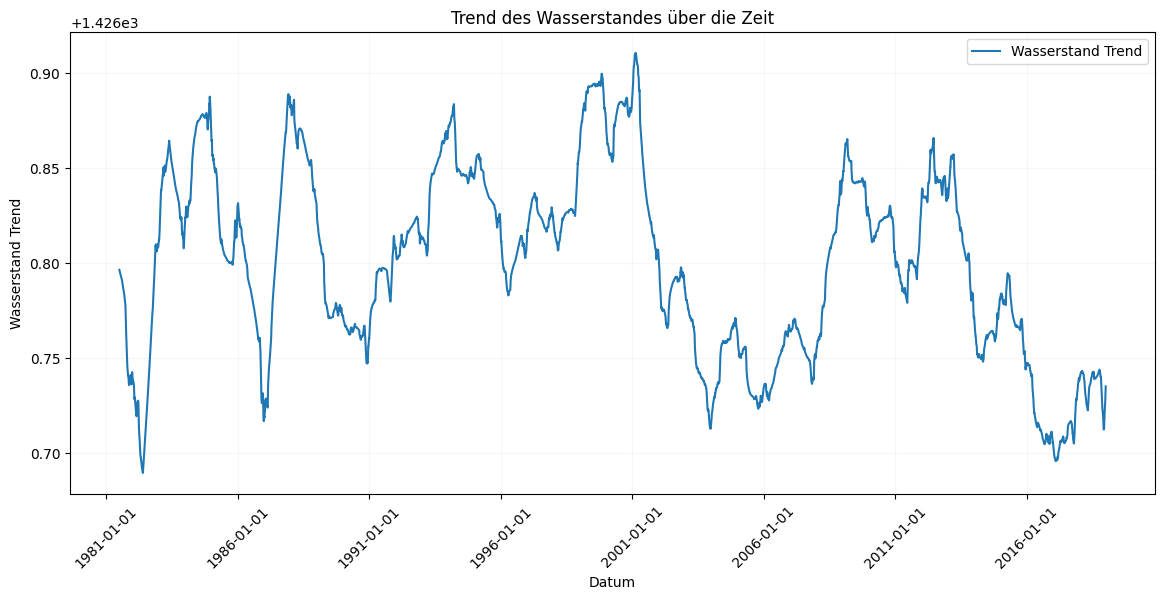

In [24]:
# Trend des Wassersatndes modellieren
# Anzeigen des Trends (Datum nur alle 5 Jahre)
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['wl_trend'], label='Wasserstand Trend')
plt.xlabel('Datum')
plt.ylabel('Wasserstand Trend')
plt.title('Trend des Wasserstandes über die Zeit')

plt.xticks(xticks, rotation=45)
plt.grid(True, alpha = 0.1)
plt.legend()

plt.show()

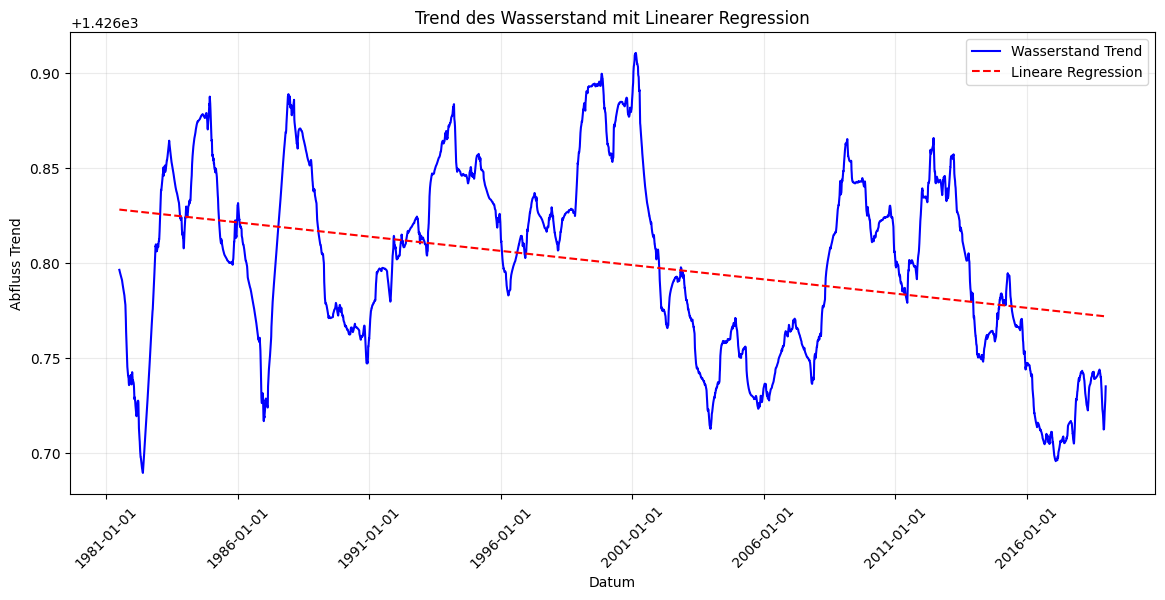

In [25]:
# Feature: Tage seit Startdatum
X = (df_train.index - df_train.index.min()).days.values.reshape(-1, 1)
y = df_train['wl_trend'].values

# Lineare Regression auf polynomiale Features
wl_trend_model = LinearRegression()
wl_trend_model.fit(X, y)

# Vorhersage
wl_trend_pred = wl_trend_model.predict(X)

# Plotten
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['wl_trend'], label='Wasserstand Trend', color='blue')
plt.plot(df_train.index, wl_trend_pred, label='Lineare Regression', color='red', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Abfluss Trend')
plt.title('Trend des Wasserstand mit Linearer Regression')
plt.xticks(xticks, rotation=45)
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()


Im obgien Polt ist zu erkennen, dass der Trend um einiges komlexer ist alse die simple gerade der linearen Regression die dargestellt und Vorhergesagt wird. Fürs Erste, wird dieser Wert als akzeptabel betrachted.

### Modellieren Saisonalität für `waterlevel(m)`

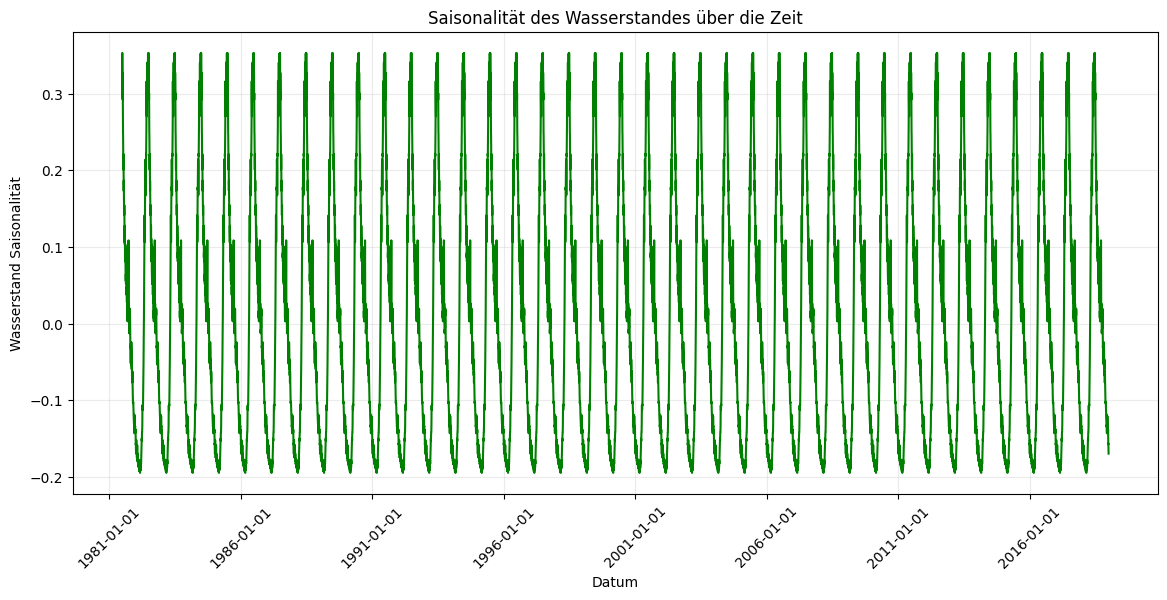

In [26]:
# Plotten der Saisonalität des Wasserstandes
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['wl_season'],  color='green')
plt.xlabel('Datum')
plt.ylabel('Wasserstand Saisonalität')
plt.title('Saisonalität des Wasserstandes über die Zeit')
plt.xticks(xticks, rotation=45)
plt.grid(True, alpha=0.25)
plt.show()

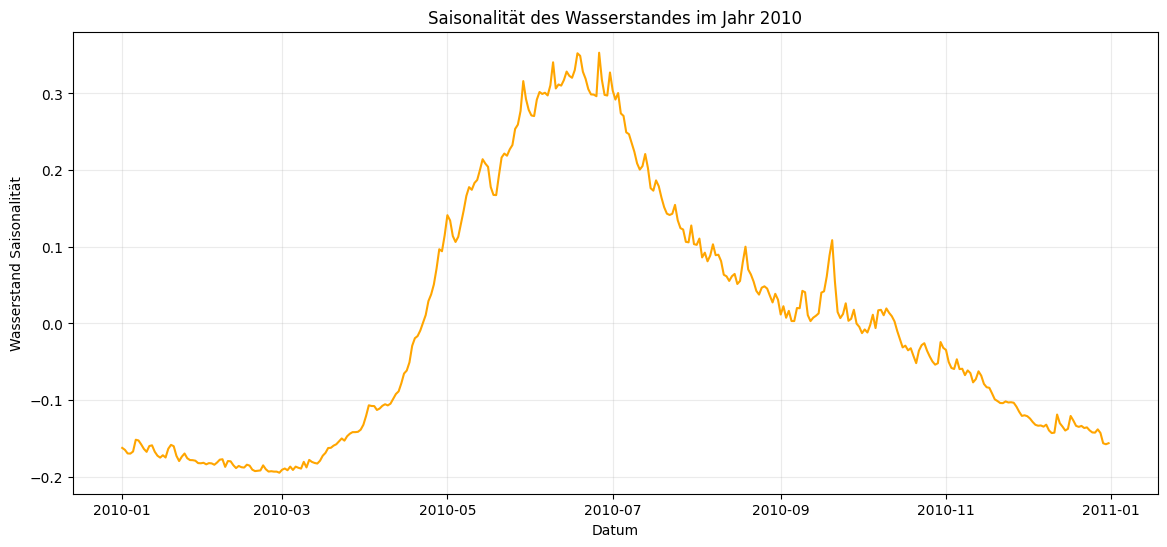

In [27]:
# Welle für ein Jahr plotten
plt.figure(figsize=(14, 6))
one_year = df_train['wl_season']['2010-01-01':'2010-12-31']
plt.plot(one_year.index, one_year.values, label='Wasserstand Saisonalität 2010', color='orange')
plt.xlabel('Datum')
plt.ylabel('Wasserstand Saisonalität')
plt.title('Saisonalität des Wasserstandes im Jahr 2010')
plt.grid(True, alpha=0.25)
plt.show()

In [28]:
df['dayofyear'] = df.index.dayofyear

# Durchschnittliche Saisonalität pro Tag des Jahres
wl_seasonal_lookup = df.groupby('dayofyear')['wl_season'].mean()

Wie beim Wasserabfluss, haben wir uns dazu entschieden, die Saisonalität durch den Durchschnittswert pro Tag des Jahres zu modellieren. In der Prognose wird dann jeweils der entsprechende Tageswert benutzt.

### Modellieren der Residuen vom `waterlevel(m)`
Auf Basis der ACF- und PACF-Analyse wird ein AR(5)-Modell verwendet.

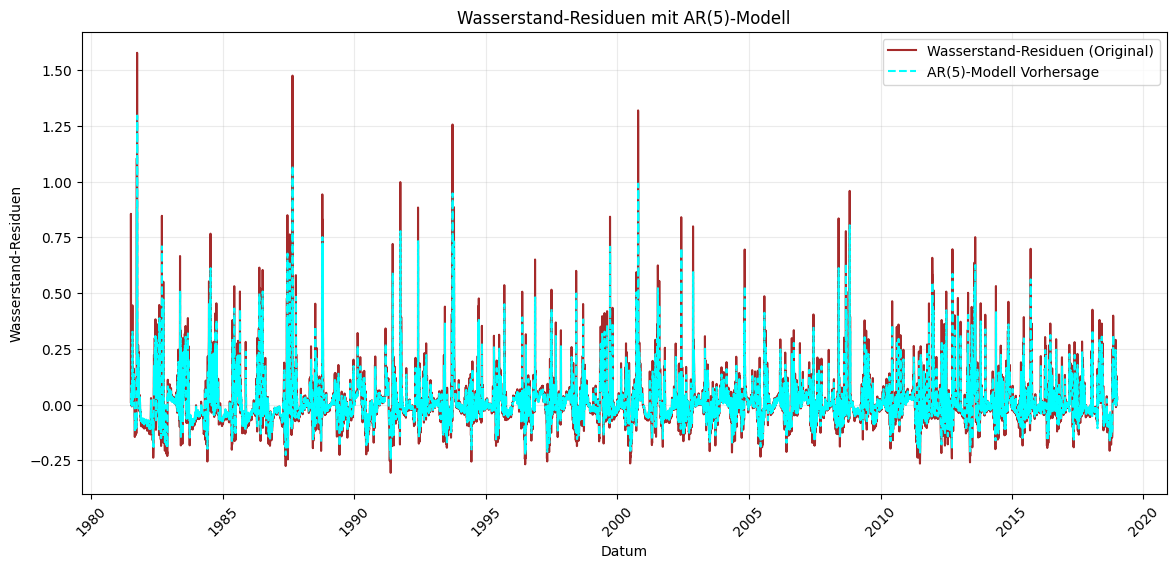

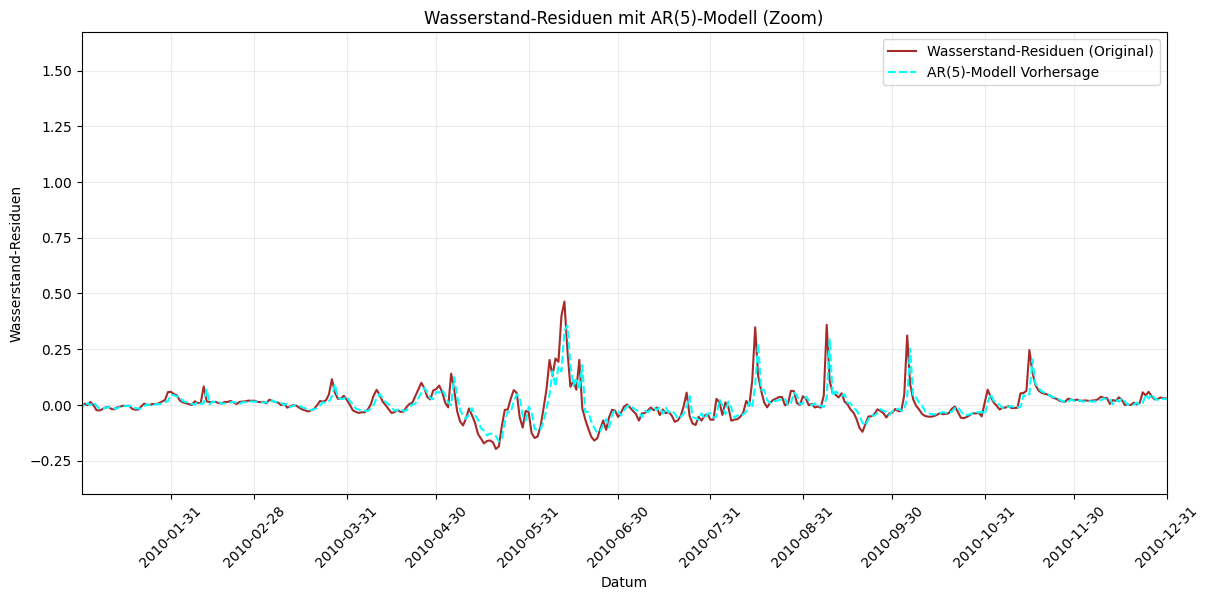

In [29]:
# AR(5) für wl_resid
ar_model_wl_5 =  AutoReg(df_train['wl_resid'], lags=5).fit()
wl_resid_pred_5 = ar_model_wl_5.predict(start=0, end=len(df_train)-1)

plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['wl_resid'], label='Wasserstand-Residuen (Original)', color='brown')
plt.plot(df_train.index, wl_resid_pred_5, label='AR(5)-Modell Vorhersage', color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.ylabel('Wasserstand-Residuen')
plt.title('Wasserstand-Residuen mit AR(5)-Modell')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()


# Zoom: nur ein Jahr
zoom_xticks = pd.date_range("2010-01-01", "2011-01-01", freq="ME")
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train['wl_resid'], label='Wasserstand-Residuen (Original)', color='brown')
plt.plot(df_train.index, wl_resid_pred_5, label='AR(5)-Modell Vorhersage', color='cyan', linestyle='--')
plt.xlabel('Datum')
plt.xlim(pd.Timestamp("2010-01-01"), pd.Timestamp("2010-12-31"))
plt.ylabel('Wasserstand-Residuen')
plt.title('Wasserstand-Residuen mit AR(5)-Modell (Zoom)')
plt.xticks(zoom_xticks, rotation=45)
plt.grid(True, alpha=0.25)
plt.legend()
plt.show();

#### Zusammensetzung des Wasserstandes

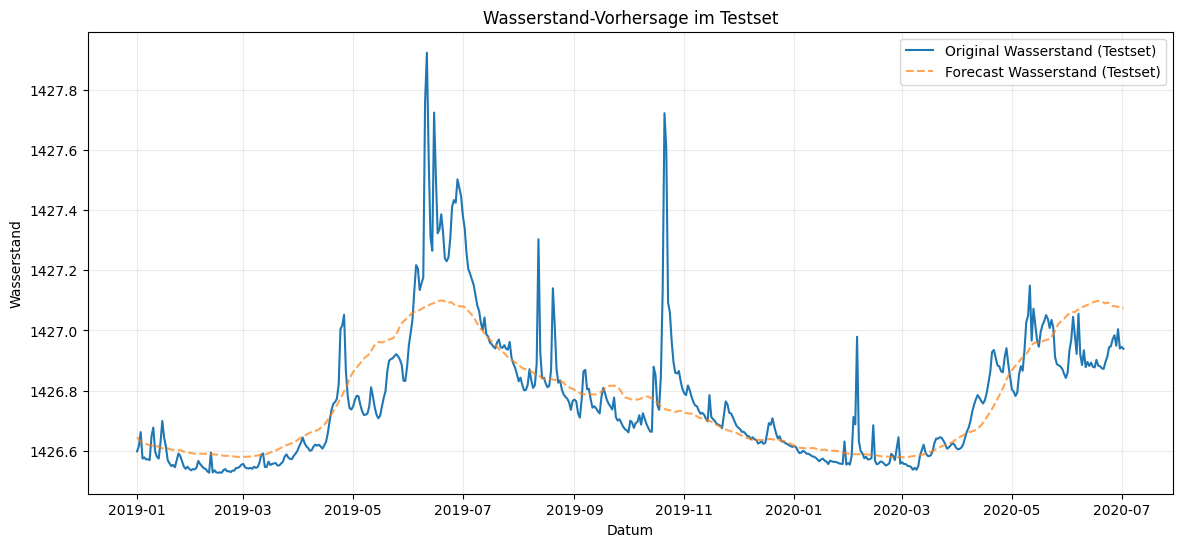

MAE: 0.07924752653746166
RMSE: 0.1310981150835199
R²: 0.6561664336306505


In [30]:
# Vorhersage des Wasserstand im Testset
# Trend für das Testset vorhersagen
X_test_days = (df_test.index - df_train.index.min()).days.values.reshape(-1, 1)
wl_trend_test_pred = wl_trend_model.predict(X_test_days)

# Saisonalität für das Testset vorhersagen
day_of_year_test = df_test.index.dayofyear.values.reshape(-1, 1)
wl_season_test_pred = wl_seasonal_lookup.loc[day_of_year_test.flatten()].values

# Residuen für das Testset vorhersagen (AR(5))
# Die letzten 5 Werte aus dem Training als Startwerte verwenden
wl_last_resid_lags = df_train['wl_resid'].iloc[-5:].values

# Eine leere Liste für die Testvorhersagen erstellen
wl_resid_test_pred = []

# Manuelle rolling prediction
for i in range(len(df_test)):
    if i < 5:
        # Für die ersten 5 Vorhersagen: Verwende tatsächliche Trainingswerte
        lags = wl_last_resid_lags[-(5-i):].tolist() + wl_resid_test_pred[:i]
    else:
        # Danach: Verwende die letzten 5 Vorhersagen
        lags = wl_resid_test_pred[-5:]
    
    # Vorhersage basierend auf den Lags
    pred = ar_model_wl_5.params.iloc[0]  # Konstante
    for j in range(min(5, len(lags))):
        pred += ar_model_wl_5.params.iloc[j+1] * lags[-(j+1)]

    
    wl_resid_test_pred.append(pred)

wl_resid_test_pred = np.array(wl_resid_test_pred)

# Gesamtes Wasserstand rekonstruieren
wl_test_forecast = (wl_trend_test_pred + 
                    wl_season_test_pred + 
                    wl_resid_test_pred)

# Visualisierung: Original vs. Forecast
plt.figure(figsize=(14,6))
plt.plot(df_test.index,
         df_test['wl_trend'] + df_test['wl_season'] + df_test['wl_resid'],
         label='Original Wasserstand (Testset)', alpha=1)

plt.plot(df_test.index, 
         wl_test_forecast,
         label='Forecast Wasserstand (Testset)', linestyle='--', alpha=0.7)
plt.xlabel("Datum")
plt.ylabel("Wasserstand")
plt.title("Wasserstand-Vorhersage im Testset")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()


# Fehlerkennzahlen
y_true = df_test['wl_trend'] + df_test['wl_season'] + df_test['wl_resid']
y_pred = wl_test_forecast

print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R²:", r2_score(y_true, y_pred))


Das Modell liefert eine solide Vorhersage. Ausreisser und Spitzern werden geglättet sind aber in einem überschaubaren Bereich.

## Extremwert Analyse

In [31]:
from scipy.stats import norm
from statsmodels.distributions import ECDF
from statsmodels.api import qqplot
from scipy.stats import genextreme


In [32]:
def plot_extreme(residuen, variablen_name):
    # Zeitliche Verteilung vernachlässigt
    fig,ax=plt.subplots()
    fig.set_size_inches(8,6)
    ax.plot(residuen,'o')
    plt.show()



    # Wie viele wie grosse Werte gibt es?
    fig,ax=plt.subplots()
    fig.set_size_inches(8,6)
    ax.hist(residuen,bins=20, density=True, label=f'Residuen {variablen_name}')

    # Wahrscheinlichkeitsdichte normalverteilt
    mu, sig = norm.fit(residuen) 
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sig)
    
    plt.plot(x, p, 'k', linewidth=2, label='Normalverteilung')
    # plt.tight_layout()
    plt.legend()
    plt.title(f'Residuen {variablen_name}')
    plt.show()
    print(mu)
    print(sig)


    # Kumulierte Wahrscheinlichkeit, Normalverteilung
    # Emipirische Verteilung
    res_cdf=ECDF(residuen)

    fig,ax=plt.subplots()
    fig.set_size_inches(8,6)

    plt.plot(x,res_cdf(x),label='Residuen')
    plt.plot(x,norm.cdf(x,mu,sig),label='Normalverteilung')
    plt.legend()
    plt.title(f'Residuen {variablen_name}')
    plt.show()

    # Quantil-Quantil, Normalverteilung
    fig=qqplot(residuen, dist=norm)
    fig.set_size_inches(8,6)
    plt.title('QQ-Plot, Normalverteilung')
    plt.show()

    fig,ax=plt.subplots()
    fig.set_size_inches(8,6)

    ax.hist(residuen, bins=20, density=True, label= f'Residuen {variablen_name}')
    
    # Wahrscheinlichkeitsdichte normalverteilt
    c, loc, scl = genextreme.fit(residuen) 
    print(c, loc, scl)

    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = genextreme.pdf(x, c, loc, scl)

    ax.plot(x, p, 'k', linewidth=2, label='GEV-Verteilung')
    plt.legend()
    plt.title(f'Residuen {variablen_name}')
    plt.show()


    # CDF, GEV-Verteilung
    fig,ax=plt.subplots()
    fig.set_size_inches(8,6)

    res_cdf=ECDF(residuen)
    plt.plot(x,res_cdf(x),label= f'Residuen {variablen_name}')
    plt.plot(x,genextreme.cdf(x, c, loc, scl),label='GEV-Verteilung')
    plt.legend()
    plt.title(f'Residuen {variablen_name}')
    plt.show()

    # QQ-Plot, GEV-Verteilung
    c, loc, scl = genextreme.fit(residuen)
    fig=qqplot(residuen, dist=genextreme, distargs=(c,), loc=loc, scale=scl)
    fig.set_size_inches(8,6)
    plt.title(f'QQ-Plot, GEV-Verteilung, c: {c:.3f}')
    plt.show()

    # QQ-Plot, Zensierte GEV-Verteilung
    u = np.quantile(residuen, 0.975)   # oder 0.9 / 0.975 je nach Daten
    Res_filt = residuen[residuen > u]
    c, loc, scl = genextreme.fit(Res_filt)
    fig=qqplot(Res_filt, dist=genextreme, distargs=(c,), loc=loc, scale=scl)
    fig.set_size_inches(8,6)
    plt.title(f'QQ-Plot, GEV-Verteilung, c: {c:.3f}')
    plt.show()

    # Vergleich Formparameter
    x=np.linspace(-4, 4, 100)

    c1, loc1, scl1 = 0.8, loc, scl
    fig,ax=plt.subplots(figsize=(8,5.5))
    ax.plot(x, genextreme.cdf(x, c, loc, scl), label=f'c: {c:.3f}, loc: {loc:.3f}, scl: {scl:.3f}',color='blue')
    ax.plot(x, genextreme.cdf(x, c1, loc1, scl1), label=f'c: {c1:.3f}, loc: {loc1:.3f}, scl: {scl1:.3f}',color='red')
    plt.title('GEV-Verteilungen, CDF')
    plt.legend()
    plt.show()

In [33]:
def run_eva_for(resid, name, block_size='365D', pot_q=0.95):
    import warnings
    from pyextremes import EVA
    data = resid.dropna()
    print(f"\n==== EVA für {name} — n={data.size} Punkte ====")
    if data.size < 30:
        print('Zu wenige Datenpunkte für EVA. Überspringe.')
        return

    # Block-Maxima (BM)
    try:
        Modell_BM = EVA(data)
        Modell_BM.get_extremes(method='BM', block_size=block_size, extremes_type='high')
        Modell_BM.plot_extremes() 
        plt.show()

        Modell_BM.fit_model(distribution='genextreme')
        Modell_BM.plot_diagnostic()
        plt.show()

        summary_bm = Modell_BM.get_summary(return_period=[10,100], alpha=0.95, n_samples=1000)
        print('BM (Block Maxima) summary:\n', summary_bm)
    except Exception as e:
        warnings.warn(f'BM failed for {name}: {e}')

    # POT (Peaks Over Threshold)
    try:
        q = np.quantile(data, pot_q)
        Modell_POT = EVA(data)
        # Try with 'decluster' first; if the installed pyextremes doesn't accept it, fall back.
        try:
            Modell_POT.get_extremes(method='POT', threshold=q, extremes_type='high', decluster=True)
        except TypeError:
            try:
                Modell_POT.get_extremes(method='POT', threshold=q, extremes_type='high')
                print("pyextremes.get_extremes doesn't accept 'decluster'; running POT without declustering.")
            except Exception as e_inner:
                raise e_inner

        Modell_POT.plot_extremes()
        plt.show()
        # For POT, fit the Generalized Pareto Distribution (GPD) per Pickands-Balkema-de Haan theorem
        try:
            Modell_POT.fit_model(distribution='genpareto')
        except Exception as e_fit:
            warnings.warn(f"Fitting 'genpareto' failed: {e_fit}. Falling back to 'genextreme'.")
            Modell_POT.fit_model(distribution='genextreme')

        Modell_POT.plot_diagnostic()
        plt.show()
        summary_pot = Modell_POT.get_summary(return_period=[10,100], alpha=0.95, n_samples=1000)
        print('POT (Peaks‑over‑Threshold) summary:\n', summary_pot)
    except Exception as e:
        warnings.warn(f'POT failed for {name}: {e}')

### Wasserstand


==== EVA für Wasserstand — n=13698 Punkte ====


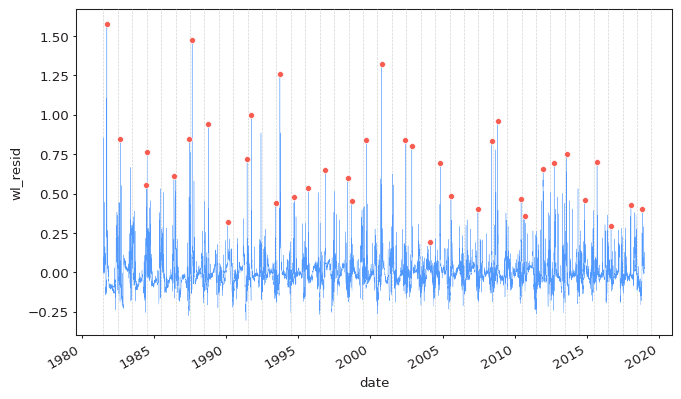

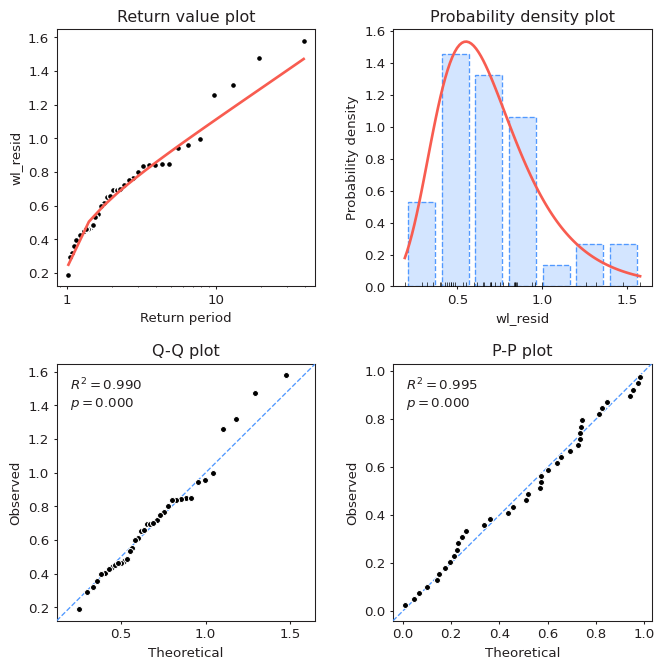

BM (Block Maxima) summary:
                return value  lower ci  upper ci
return period                                  
10.0               1.111186  0.915641  1.304175
100.0              1.723464  1.237501  2.754508
pyextremes.get_extremes doesn't accept 'decluster'; running POT without declustering.


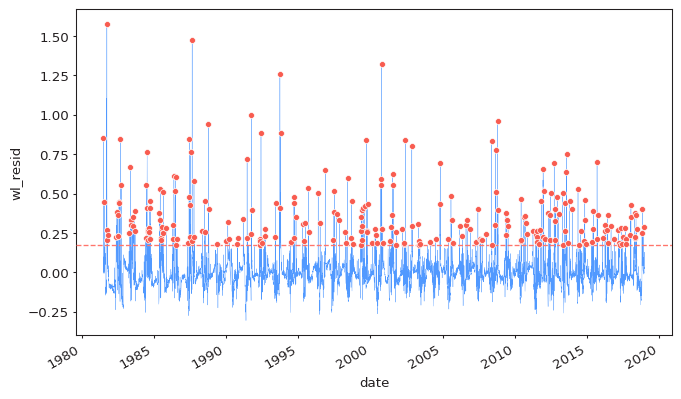

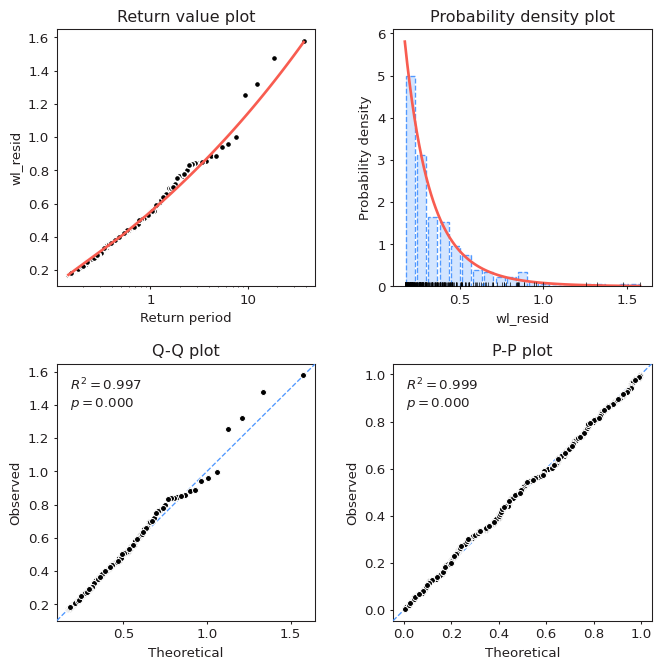

POT (Peaks‑over‑Threshold) summary:
                return value  lower ci  upper ci
return period                                  
10.0               1.141854  0.935494  1.369236
100.0              1.939981  1.365470  2.731374


In [34]:
wl_resid = df_train['wl_resid']
run_eva_for(wl_resid, 'Wasserstand', block_size='365D', pot_q=0.95);

- **Extrem-Quantile:** 95% = 1427.169, 99% = 1427.417, 99.9% = 1427.844
- **Häufigkeit starker Ereignisse:** >95%: 730 Tage; >99%: 14 Tage
- **Annual maxima:** Mittel jährl. Maximum ≈ 1427.637, Max über Beobachtungszeitraum = 1428.462 (1981). Top-Jahre: 1981, 1987, 1993, 2000, 1992.
- **POT (95%-Schwelle):** Schwelle = 1427.169, n_exceed = 730, mean excess ≈ 0.159 m.
- **Tail / GPD:** Fit: shape ≈ 0.108, scale ≈ 0.141 → leichter bis moderat schwerer rechter Schwanz (kein sehr extremer Divergenz).
- **Residuenqualität:** RMSE ≈ 0.109, MAE ≈ 0.0686, Resid-Mittel ≈ 0 → Zerlegung rekonstruiert die Serie gut, wenige Ausreisser (max resid ≈ 1.578, min ≈ -0.306
- **Interpretation / Risiko:** Basiswert (~1426.8) dominiert; Extremereignisse erscheinen als ~0.16–1.6 m Aufschwung über Basis. Prüfe Koinzidenz mit Spitzen in discharge/rain

### Temperatur


==== EVA für Temperatur — n=13698 Punkte ====


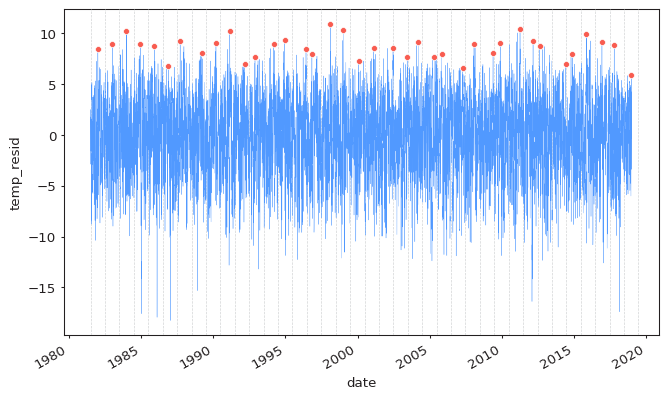

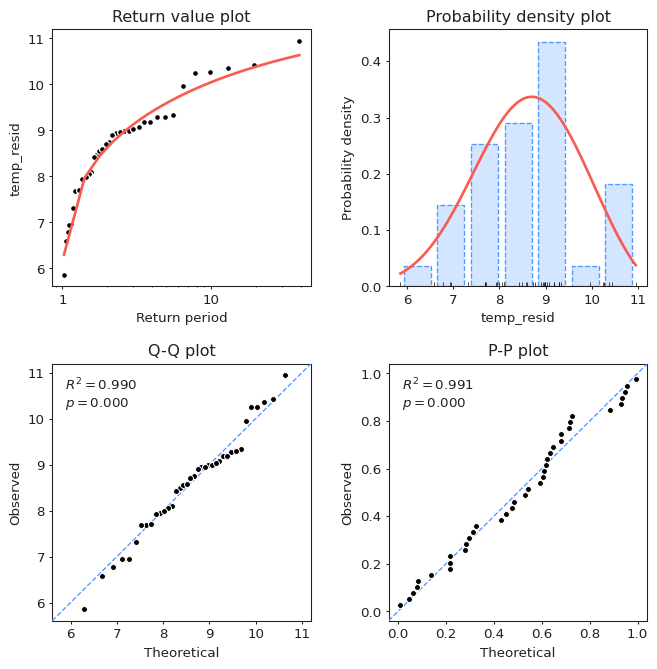

BM (Block Maxima) summary:
                return value   lower ci   upper ci
return period                                    
10.0              10.050014   9.544044  10.366172
100.0             10.899890  10.244345  11.381809
pyextremes.get_extremes doesn't accept 'decluster'; running POT without declustering.


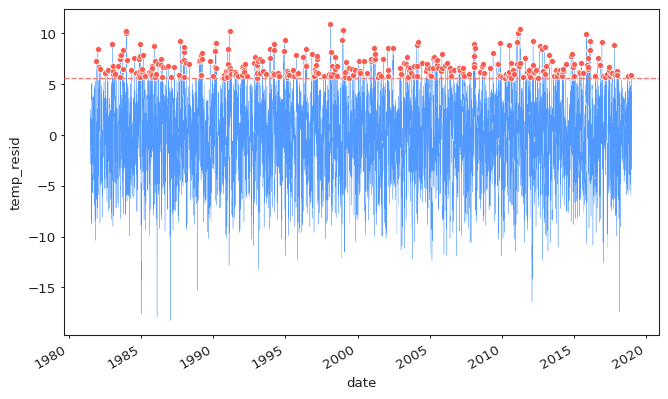

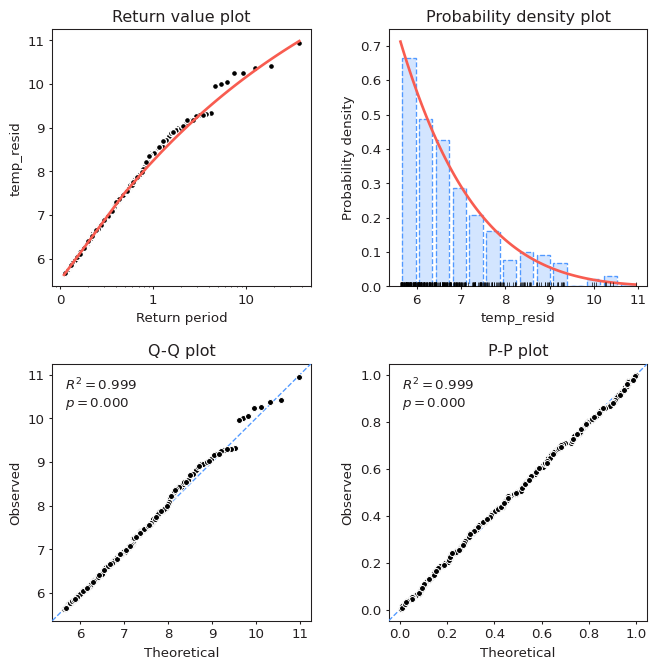

POT (Peaks‑over‑Threshold) summary:
                return value   lower ci   upper ci
return period                                    
10.0              10.157140   9.692323  10.606441
100.0             11.492876  10.597139  12.536295


In [35]:
temp_resid = df_train['temp_resid']
run_eva_for(temp_resid, 'Temperatur', block_size='365D', pot_q=0.95);

`temperature` hat weniger schweren rechten Schwanz (shape<0)

Extremhitze vorhanden (2019), aber statistisch begrenzter höchster Wert.

### Abfluss


==== EVA für Abfluss — n=13698 Punkte ====


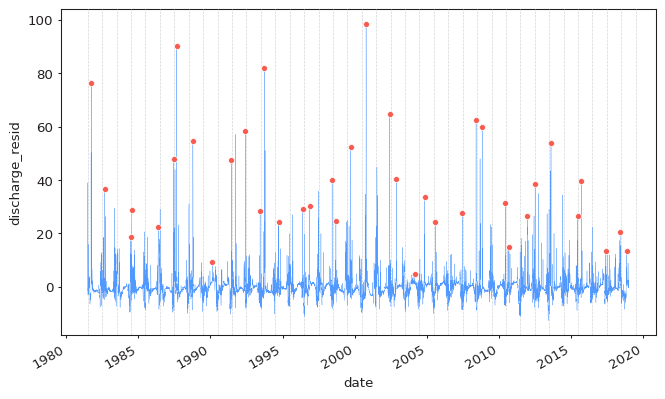

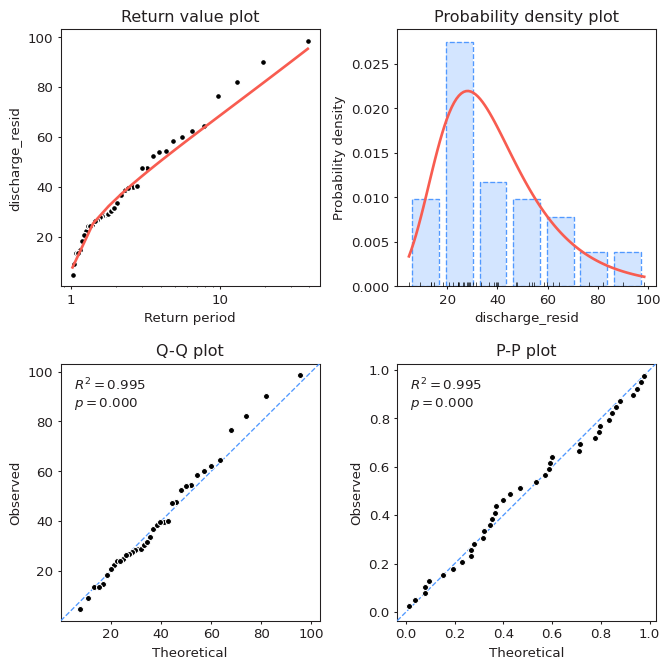

BM (Block Maxima) summary:
                return value   lower ci    upper ci
return period                                     
10.0              68.591173  55.132681   82.305896
100.0            114.626127  78.720202  171.439281
pyextremes.get_extremes doesn't accept 'decluster'; running POT without declustering.


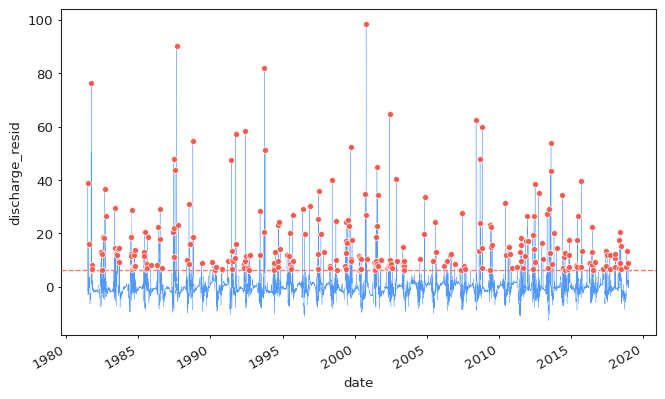

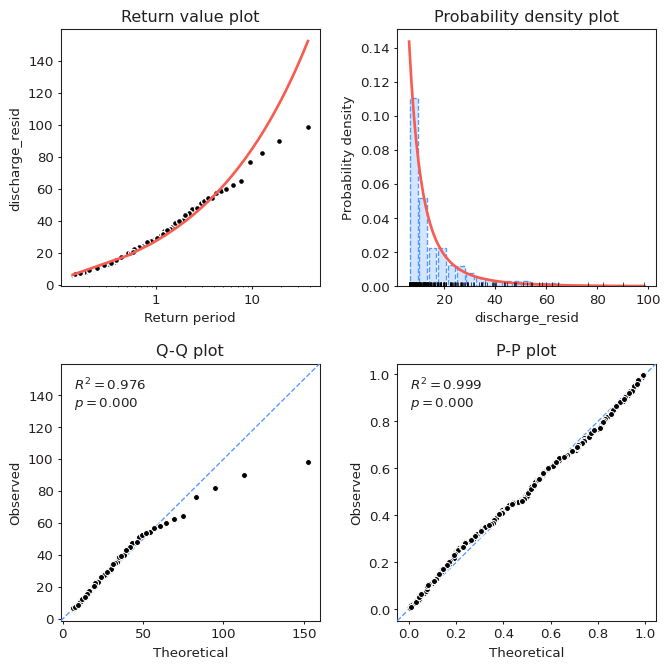

POT (Peaks‑over‑Threshold) summary:
                return value    lower ci    upper ci
return period                                      
10.0              85.349245   63.647194  113.542945
100.0            230.497520  131.362298  405.214850


In [36]:
discharge_resid = df_train['discharge_resid']
run_eva_for(discharge_resid, 'Abfluss', block_size='365D', pot_q=0.95);

`discharge` zeigt den stärksten schweren Schwanz (shape>0) --> hohe Extremrisiken

Wenn mehr Zeit--> Priorität für Risikoanalyse und Hochwasser-Checks

### Niederschlag


==== EVA für Niederschlag — n=13698 Punkte ====


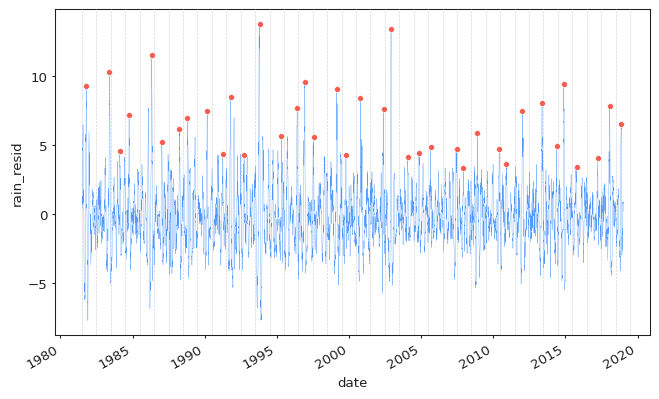

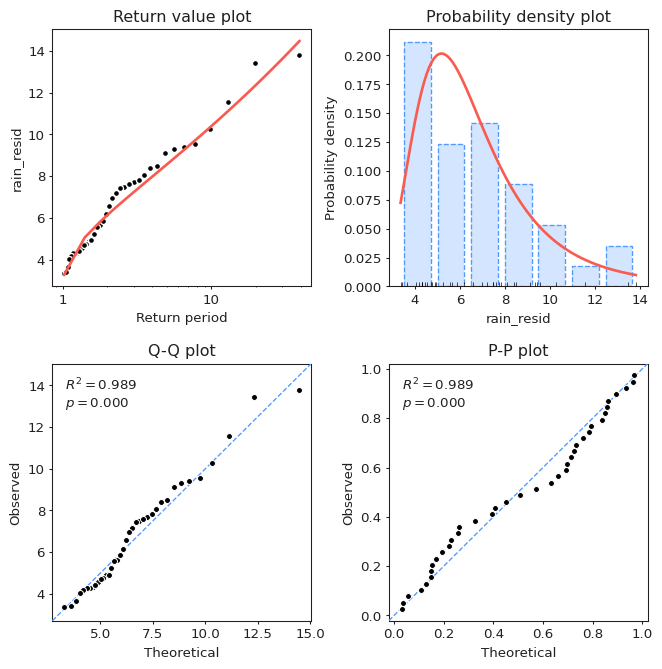

BM (Block Maxima) summary:
                return value   lower ci   upper ci
return period                                    
10.0              10.404178   8.698238  12.359419
100.0             17.796565  11.773550  35.602720
pyextremes.get_extremes doesn't accept 'decluster'; running POT without declustering.


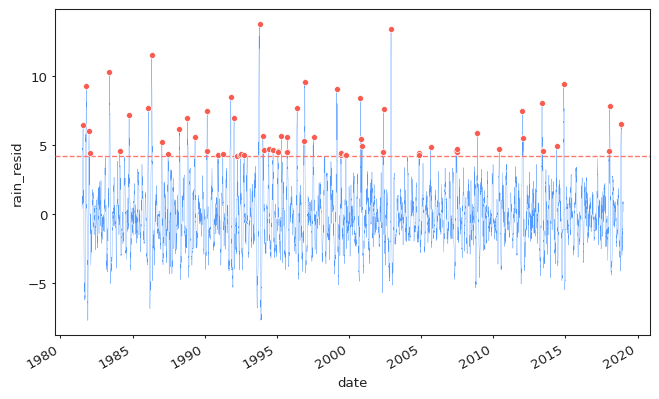

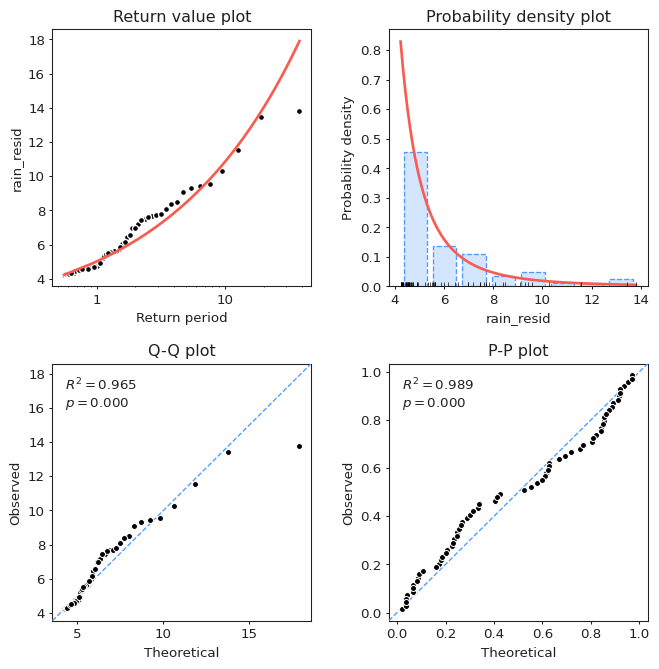

POT (Peaks‑over‑Threshold) summary:
                return value   lower ci   upper ci
return period                                    
10.0              10.836965   8.947123  13.669396
100.0             26.120472  13.288570  68.789835


In [37]:
rain_resid = df_train['rain_resid']
run_eva_for(rain_resid, 'Niederschlag', block_size='365D', pot_q=0.95);